# Maestria en Inteligencia Artificial Aplicada
# Tecnologico de Monterrey
# Proyecto Integrador "Implementación de una solución LLM en la nube para la interpretación de LSM"
# Equipo 50

In [ ]:
# Librerías y paquetes que requeridos

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

from sklearn.decomposition import TruncatedSVD

from google.colab import drive
drive.mount('/content/drive')

DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/"
os.chdir(DIR)

!pip install kaggle opencv-python pillow tqdm pandas numpy matplotlib scikit-learn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# Conexion a Kaggle

import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_b2bef2ceb350cfcc7e8d88bb9aace76d"

!pip install kaggle

!kaggle datasets list -s "mexican sign language"

!mkdir -p data/msl_abc

!kaggle datasets download \
-d jhoanborges/msl-abc-v2-mexican-sign-lang-static \
-p data/msl_abc \
--unzip

!mkdir -p data/msl_warcoder

!kaggle datasets download \
-d warcoder/mexican-sign-language-dataset \
-p data/msl_warcoder \
--unzip

!find data -type f \( -name "*.jpg" -o -name "*.jpeg" -o -name "*.png" -o -name "*.webp" \) | wc -l


ref                                         title                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------  ------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
warcoder/mexican-sign-language-dataset      Mexican Sign Language Dataset   3711566066  2023-09-18 12:14:27.223000            398         10  0.6875           
sujaykapadnis/mexicansign-language-dataset  [Mexican]Sign Language Dataset  1886977729  2023-11-24 03:42:39.880000            111          9  0.6875           
Dataset URL: https://www.kaggle.com/datasets/jhoanborges/msl-abc-v2-mexican-sign-lang-static
License(s): MIT
100% 4.65G/4.65G [00:50<00:00, 99.0MB/s]

Dataset URL: https://www.kaggle.com/datasets/warcoder/mexican-sign-language-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.46G/3.46G [00:37<00:00, 99.5MB/s]

311125


In [2]:
!ls data

!find data -maxdepth 3 -type d
!find data -type f | wc -l

msl_abc  msl_warcoder
data
data/msl_warcoder
data/msl_warcoder/Mexican sign language dataset
data/msl_warcoder/Mexican sign language dataset/MSLwords1
data/msl_abc
data/msl_abc/MSL-ABC
data/msl_abc/MSL-ABC/lsm-abc-B
data/msl_abc/MSL-ABC/lsm-abc-A
data/msl_abc/MSL-ABC/lsm-abc-C
313573


# **Análisis Exploratorio**

In [3]:
!pip install -q opencv-python pillow tqdm pandas numpy matplotlib scikit-learn
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [4]:
# Rutas de los datasets
DATASETS = {
    "MSL_ABC_STATIC": "data/msl_abc",
    "MSL_WARCODER": "data/msl_warcoder"
}

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
video_extensions = (".mp4", ".avi", ".mov", ".mkv")
!find data -maxdepth 3 -type d
!find data -type f | wc -l

data
data/msl_warcoder
data/msl_warcoder/Mexican sign language dataset
data/msl_warcoder/Mexican sign language dataset/MSLwords1
data/msl_abc
data/msl_abc/MSL-ABC
data/msl_abc/MSL-ABC/lsm-abc-B
data/msl_abc/MSL-ABC/lsm-abc-A
data/msl_abc/MSL-ABC/lsm-abc-C
313573


In [5]:
#Separar imágenes y videos
image_files = []
video_files = []
other_files = []

for dataset_name, root_path in DATASETS.items():
    for root, dirs, files in os.walk(root_path):
        for file in files:
            path = os.path.join(root, file)
            ext = file.lower()

            if ext.endswith(image_extensions):
                image_files.append({
                    "dataset": dataset_name,
                    "path": path,
                    "filename": file,
                    "label": os.path.basename(os.path.dirname(path))
                })

            elif ext.endswith(video_extensions):
                video_files.append({
                    "dataset": dataset_name,
                    "path": path,
                    "filename": file,
                    "label": os.path.basename(os.path.dirname(path))
                })

            else:
                other_files.append({
                    "dataset": dataset_name,
                    "path": path,
                    "filename": file,
                    "label": os.path.basename(os.path.dirname(path))
                })

print("Total de imágenes:", len(image_files))
print("Total de videos:", len(video_files))
print("Otros archivos:", len(other_files))

Total de imágenes: 311125
Total de videos: 2447
Otros archivos: 1


In [6]:
#Crear Dataframe de las imagenes
records = []
bad_images = []

for item in tqdm(image_files):
    path = item["path"]

    try:
        img = Image.open(path)
        width, height = img.size
        mode = img.mode

        img_cv = cv2.imread(path)

        if img_cv is not None:
            if len(img_cv.shape) == 3:
                channels = img_cv.shape[2]
                gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
            else:
                channels = 1
                gray = img_cv

            mean_brightness = np.mean(gray)
            std_brightness = np.std(gray)
        else:
            channels = None
            mean_brightness = None
            std_brightness = None

        file_size_kb = os.path.getsize(path) / 1024
        aspect_ratio = width / height if height != 0 else None

        records.append({
            "dataset": item["dataset"],
            "path": path,
            "filename": item["filename"],
            "label": item["label"],
            "width": width,
            "height": height,
            "mode": mode,
            "channels": channels,
            "file_size_kb": file_size_kb,
            "aspect_ratio": aspect_ratio,
            "mean_brightness": mean_brightness,
            "std_brightness": std_brightness
        })

    except Exception as e:
        bad_images.append(path)

df = pd.DataFrame(records)

print("Imágenes válidas:", len(df))
print("Imágenes corruptas o no legibles:", len(bad_images))

df.head()

100%|██████████| 311125/311125 [18:04<00:00, 286.89it/s]


Imágenes válidas: 311125
Imágenes corruptas o no legibles: 0


,dataset,path,filename,label,width,height,mode,channels,file_size_kb,aspect_ratio,mean_brightness,std_brightness
0,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-3...,S18-M-3-29.jpg,10,360,360,RGB,3,16.331055,1.0,107.779769,19.240856
1,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S20-M-2...,S20-M-2-36.jpg,10,360,360,RGB,3,17.469727,1.0,117.632346,11.554279
2,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-3...,S18-M-3-19.jpg,10,360,360,RGB,3,13.806641,1.0,107.910895,19.155192
3,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-2...,S18-M-2-30.jpg,10,360,360,RGB,3,19.101562,1.0,110.864468,18.984211
4,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-2...,S18-M-2-16.jpg,10,360,360,RGB,3,15.196289,1.0,110.065826,19.730439


In [7]:
#Crear Dataframes de los videos

video_records = []
bad_videos = []

for item in tqdm(video_files):
    path = item["path"]

    try:
        cap = cv2.VideoCapture(path)

        if cap.isOpened():
            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
            width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
            height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

            duration_seconds = frame_count / fps if fps and fps > 0 else None

            video_records.append({
                "dataset": item["dataset"],
                "path": path,
                "filename": item["filename"],
                "label": item["label"],
                "width": width,
                "height": height,
                "fps": fps,
                "frame_count": frame_count,
                "duration_seconds": duration_seconds,
                "file_size_mb": os.path.getsize(path) / (1024 * 1024)
            })

        else:
            bad_videos.append(path)

        cap.release()

    except Exception as e:
        bad_videos.append(path)

df_videos = pd.DataFrame(video_records)

print("Videos válidos:", len(df_videos))
print("Videos corruptos o no legibles:", len(bad_videos))

df_videos.head()

100%|██████████| 2447/2447 [00:24<00:00, 100.19it/s]


Videos válidos: 2447
Videos corruptos o no legibles: 0


,dataset,path,filename,label,width,height,fps,frame_count,duration_seconds,file_size_mb
0,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,135.mov,05135,640.0,480.0,30.00000,55.0,1.833333,0.519176
1,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,135.mov,04135,640.0,480.0,30.00000,50.0,1.666667,0.134336
2,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,135.mov,02135,1920.0,1080.0,30.00003,97.0,3.233330,0.628232
3,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,135.mp4,09135,640.0,480.0,30.00000,60.0,2.000000,1.563730
4,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,135.mov,10135,640.0,480.0,30.00000,56.0,1.866667,0.617664


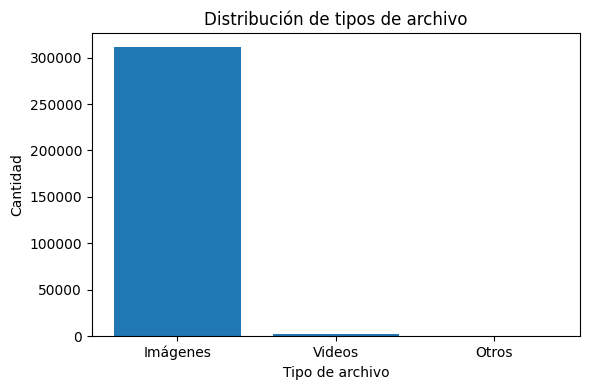

In [8]:
# Información general de los archivos
file_summary = pd.DataFrame({
    "tipo_archivo": ["Imágenes", "Videos", "Otros"],
    "cantidad": [len(image_files), len(video_files), len(other_files)]
})

file_summary

plt.figure(figsize=(6, 4))
plt.bar(file_summary["tipo_archivo"], file_summary["cantidad"])
plt.title("Distribución de tipos de archivo")
plt.xlabel("Tipo de archivo")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

El conjunto de datos contiene archivos de imagen y video. Para este primer avance, el análisis exploratorio se enfoca principalmente en imágenes estáticas, ya que permiten una evaluación inicial de clases, resolución, tamaño, brillo y balance de datos. Los videos se identificaron como parte del inventario y podrán analizarse posteriormente mediante extracción de frames.

In [9]:
#Estadisticas Generales

df.info()

df.describe(include="all")

summary_dataset = df.groupby("dataset").agg(
    total_images=("path", "count"),
    total_classes=("label", "nunique"),
    avg_width=("width", "mean"),
    avg_height=("height", "mean"),
    avg_file_size_kb=("file_size_kb", "mean"),
    avg_brightness=("mean_brightness", "mean")
).reset_index()

summary_dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311125 entries, 0 to 311124
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   dataset          311125 non-null  object 
 1   path             311125 non-null  object 
 2   filename         311125 non-null  object 
 3   label            311125 non-null  object 
 4   width            311125 non-null  int64  
 5   height           311125 non-null  int64  
 6   mode             311125 non-null  object 
 7   channels         311125 non-null  int64  
 8   file_size_kb     311125 non-null  float64
 9   aspect_ratio     311125 non-null  float64
 10  mean_brightness  311125 non-null  float64
 11  std_brightness   311125 non-null  float64
dtypes: float64(4), int64(3), object(5)
memory usage: 28.5+ MB


,dataset,total_images,total_classes,avg_width,avg_height,avg_file_size_kb,avg_brightness
0,MSL_ABC_STATIC,279716,21,360.000000,359.995885,17.421268,116.132722
1,MSL_WARCODER,31409,2446,640.050941,480.038206,33.838104,25.779932


Se consolidó una tabla maestra donde cada imagen representa una observación. A partir de esta estructura se analizaron variables como dataset de origen, clase, resolución, tamaño de archivo, proporción de imagen y brillo promedio. Esto permite aplicar técnicas estadísticas sobre datos originalmente no estructurados.

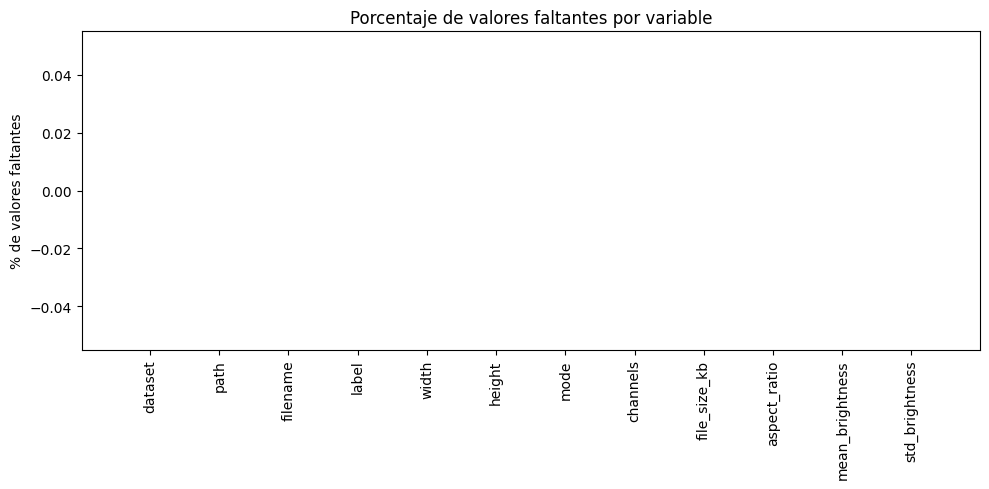

In [10]:
# Missing values

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "missing_values": missing_values,
    "missing_percent": missing_percent
})

missing_report

plt.figure(figsize=(10, 5))
plt.bar(missing_report.index, missing_report["missing_percent"])
plt.xticks(rotation=90)
plt.ylabel("% de valores faltantes")
plt.title("Porcentaje de valores faltantes por variable")
plt.tight_layout()
plt.show()

No se identificaron valores faltantes relevantes en las variables principales del conjunto de imágenes. Las imágenes corruptas o no legibles fueron excluidas del análisis para evitar errores durante el preprocesamiento y entrenamiento posterior.

In [11]:
# Cardinalidad de variables categoricas

categorical_cols = ["dataset", "label", "mode", "channels"]

cardinality = pd.DataFrame({
    "variable": categorical_cols,
    "unique_values": [df[col].nunique() for col in categorical_cols]
})

cardinality

print("Clases detectadas:")
print(sorted(df["label"].unique()))

Clases detectadas:
['0', '01001', '01002', '01003', '01004', '01005', '01006', '01007', '01008', '01009', '01010', '01013', '01014', '01015', '01016', '01017', '01018', '01019', '01020', '01021', '01022', '01023', '01024', '01025', '01026', '01027', '01028', '01029', '01030', '01031', '01032', '01033', '01034', '01035', '01036', '01037', '01038', '01039', '01040', '01041', '01042', '01043', '01044', '01045', '01046', '01047', '01048', '01049', '01050', '01051', '01052', '01053', '01054', '01055', '01056', '01057', '01058', '01059', '01060', '01061', '01062', '01063', '01064', '01065', '01066', '01067', '01068', '01069', '01070', '01071', '01072', '01073', '01074', '01075', '01076', '01077', '01078', '01079', '01080', '01081', '01082', '01083', '01084', '01085', '01086', '01087', '01088', '01089', '01090', '01091', '01092', '01093', '01094', '01095', '01096', '01097', '01098', '01099', '01100', '01101', '01102', '01103', '01104', '01105', '01106', '01107', '01108', '01109', '01110', '01

La variable objetivo corresponde a la clase o seña representada en cada imagen. La cardinalidad de esta variable indica que se trata de un problema de clasificación multiclase. Revisar la cardinalidad es importante para confirmar cuántas categorías deberá aprender el modelo.

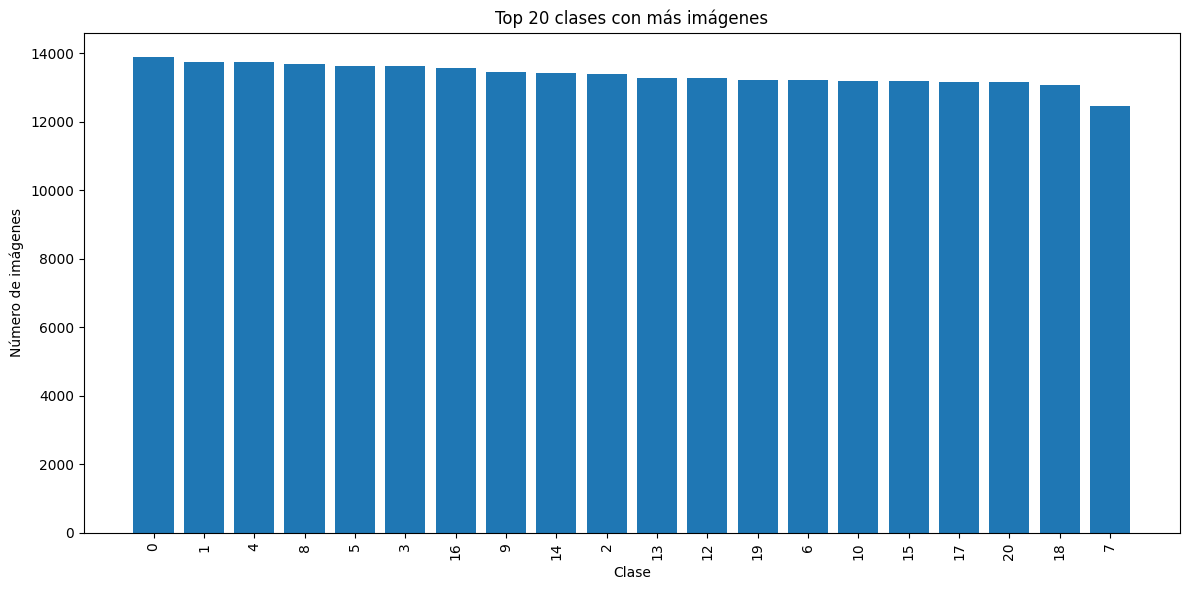

In [13]:
#Distribución de Clases

# Distribución de clases
class_counts = df["label"].value_counts().reset_index()
class_counts.columns = ["clase", "count"]
class_counts["percentage"] = class_counts["count"] / class_counts["count"].sum() * 100

class_counts.head(20)


import matplotlib.pyplot as plt

top_n = 20
top_classes = class_counts.head(top_n)

plt.figure(figsize=(12, 6))
plt.bar(top_classes["clase"], top_classes["count"])
plt.xticks(rotation=90)
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.title(f"Top {top_n} clases con más imágenes")
plt.tight_layout()
plt.show()

Las 20 clases con mayor cantidad de imágenes tienen volúmenes relativamente similares, entre aproximadamente 12,500 y 14,000 imágenes. Esto indica que, dentro de las clases principales, no existe un desbalance fuerte. Sin embargo, este gráfico solo muestra el Top 20, por lo que todavía es necesario revisar las clases con menor representación para confirmar si el dataset completo está balanceado.

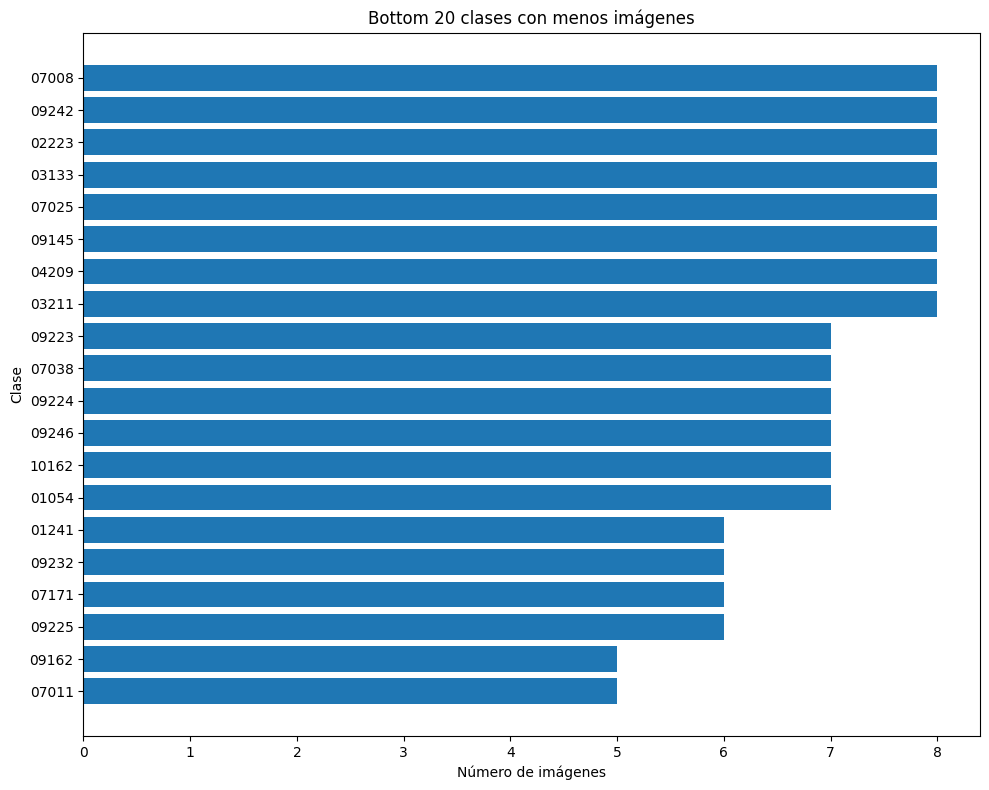

Clase con más imágenes: 13898
Clase con menos imágenes: 5
Ratio de desbalance: 2779.6


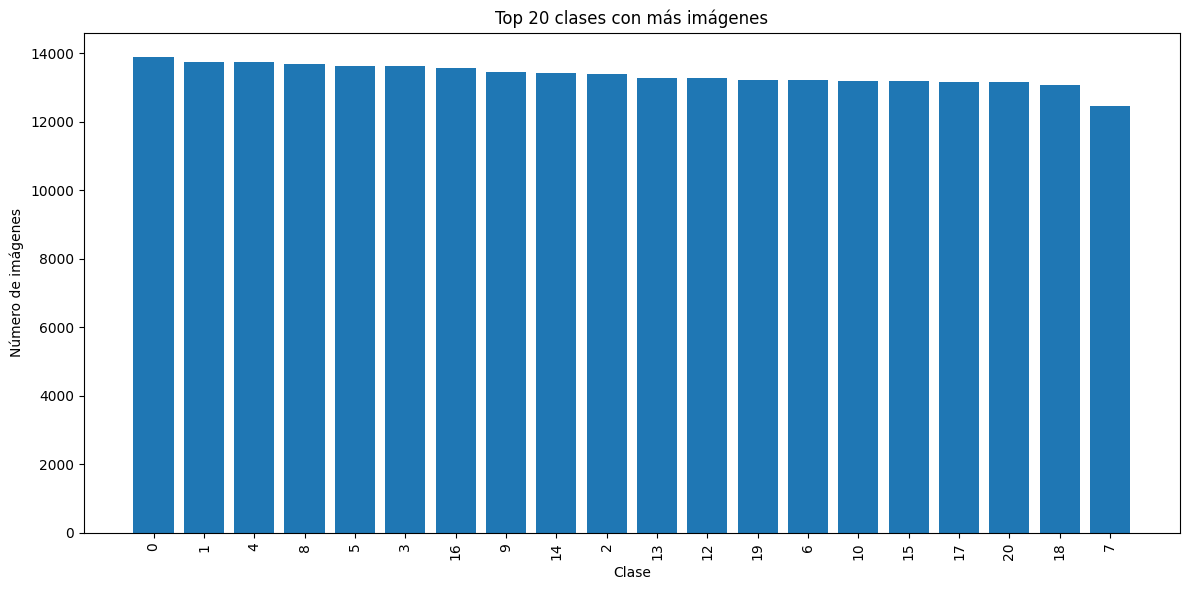

In [14]:
# Bottom 20 clases con menos imágenes
bottom_classes = class_counts.tail(20).sort_values("count")

plt.figure(figsize=(10, 8))
plt.barh(bottom_classes["clase"].astype(str), bottom_classes["count"])
plt.xlabel("Número de imágenes")
plt.ylabel("Clase")
plt.title("Bottom 20 clases con menos imágenes")
plt.tight_layout()
plt.show()

max_count = class_counts["count"].max()
min_count = class_counts["count"].min()
imbalance_ratio = max_count / min_count

print("Clase con más imágenes:", max_count)
print("Clase con menos imágenes:", min_count)
print("Ratio de desbalance:", round(imbalance_ratio, 2))

plt.figure(figsize=(12, 6))
plt.bar(top_classes["clase"].astype(str), top_classes["count"])
plt.xticks(rotation=90)
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.title("Top 20 clases con más imágenes")
plt.tight_layout()
plt.show()

Se identificó un fuerte desbalance en la distribución de clases. La clase con mayor número de imágenes contiene 13,898 observaciones, mientras que la clase con menor representación contiene únicamente 5 imágenes, generando un ratio de desbalance de 2,779.6. Esto indica que, aunque las clases más frecuentes presentan volúmenes similares, existen clases altamente subrepresentadas dentro del conjunto de datos. Este comportamiento puede afectar el entrenamiento del modelo, ya que las clases con pocas imágenes podrían no ser aprendidas correctamente. Por ello, se recomienda aplicar estrategias de preprocesamiento como filtrado de clases con muy baja frecuencia, aumento de datos, balanceo del conjunto o uso de métricas como precision, recall y F1-score por clase.

Debido al alto desbalance, se considerará eliminar o agrupar clases con muy baja representación, especialmente aquellas con menos de 50 o 100 imágenes, ya que no aportan suficientes ejemplos para que el modelo aprenda patrones visuales de forma confiable. Otra alternativa sería aplicar data augmentation para incrementar artificialmente el número de imágenes en las clases minoritarias.

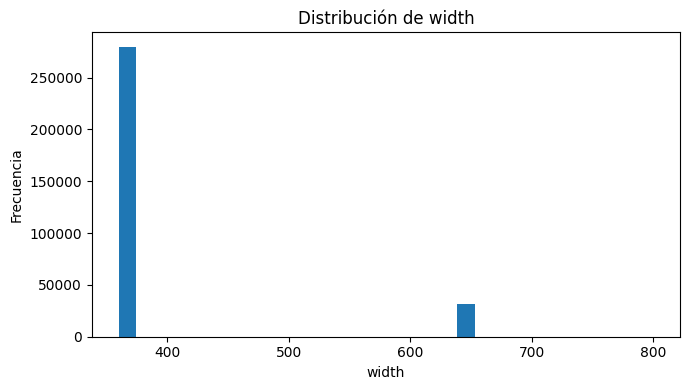

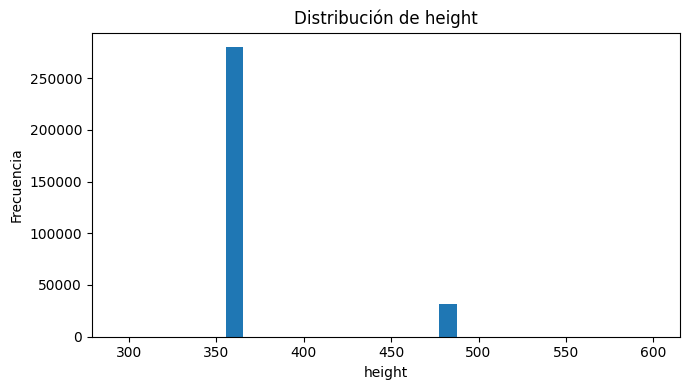

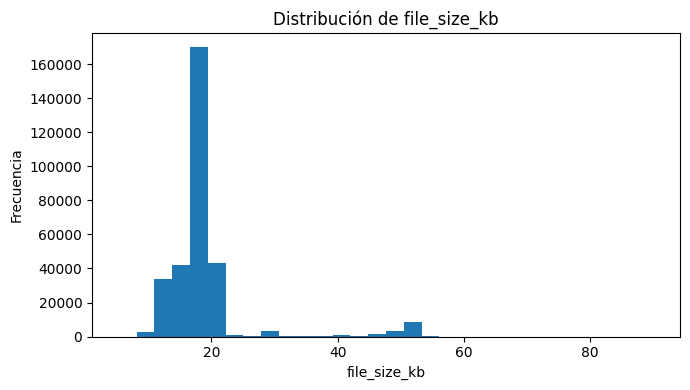

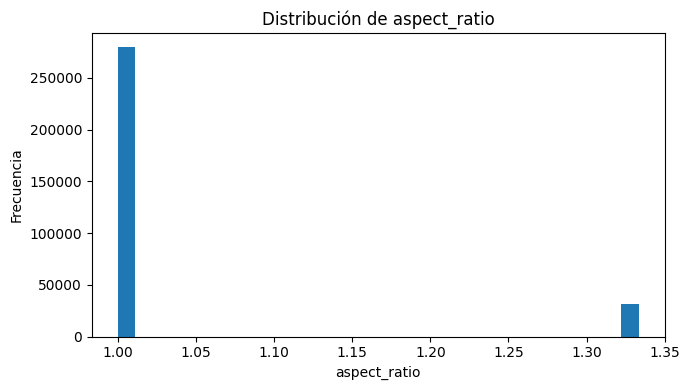

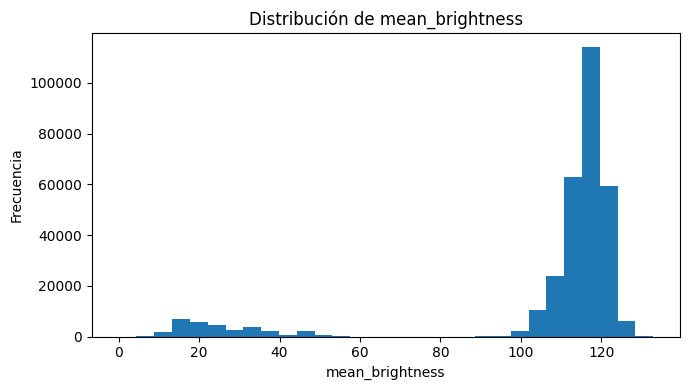

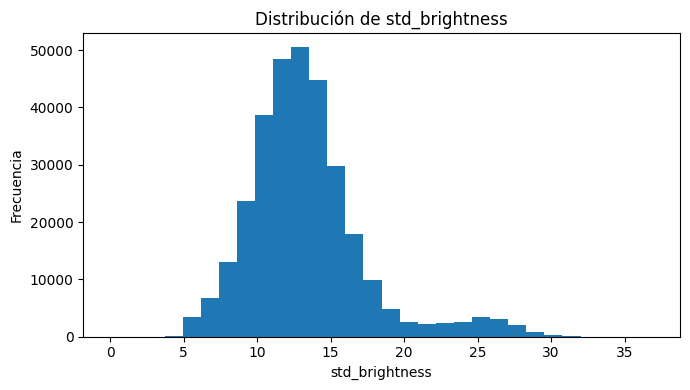

In [15]:
#Analisis univariante de variables numericas

numeric_cols = [
    "width",
    "height",
    "file_size_kb",
    "aspect_ratio",
    "mean_brightness",
    "std_brightness"
]

df[numeric_cols].describe()

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución de {col}")
    plt.tight_layout()
    plt.show()

Las variables numéricas muestran diferencias en resolución, tamaño de archivo, proporción y brillo. Estas variaciones reflejan posibles diferencias en la calidad, formato o condiciones de captura de las imágenes. Por ello se recomienda aplicar redimensionamiento y normalización antes de entrenar un modelo.

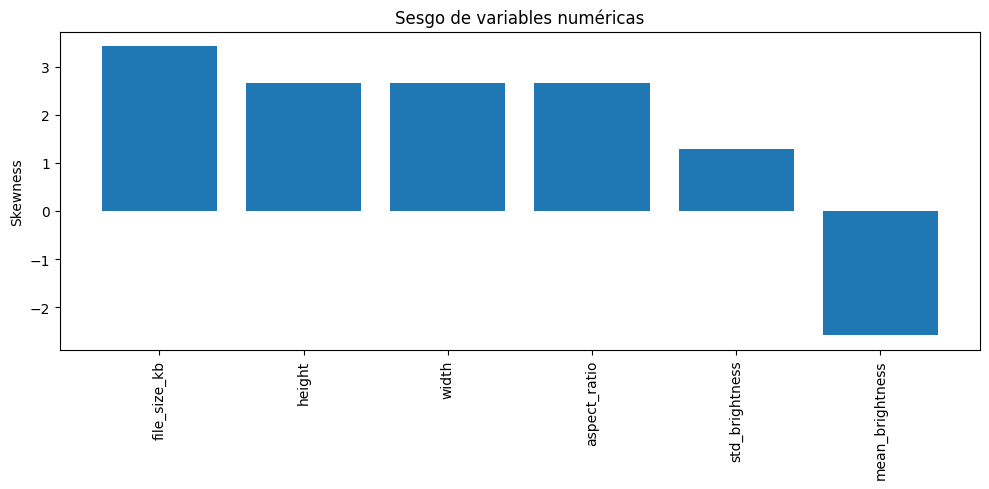

file_size_kb: distribución altamente sesgada (3.42)
height: distribución altamente sesgada (2.65)
width: distribución altamente sesgada (2.65)
aspect_ratio: distribución altamente sesgada (2.65)
std_brightness: distribución altamente sesgada (1.29)
mean_brightness: distribución altamente sesgada (-2.58)


In [16]:
#Sesgo en distribuciones

skewness = df[numeric_cols].skew().sort_values(ascending=False)

skewness

plt.figure(figsize=(10, 5))
plt.bar(skewness.index, skewness.values)
plt.xticks(rotation=90)
plt.ylabel("Skewness")
plt.title("Sesgo de variables numéricas")
plt.tight_layout()
plt.show()

for col, value in skewness.items():
    if abs(value) > 1:
        print(f"{col}: distribución altamente sesgada ({value:.2f})")
    elif abs(value) > 0.5:
        print(f"{col}: distribución moderadamente sesgada ({value:.2f})")
    else:
        print(f"{col}: distribución aproximadamente simétrica ({value:.2f})")

Se identificaron distribuciones altamente sesgadas en varias características de las imágenes. Las variables file_size_kb, height, width y aspect_ratio presentan sesgo positivo, lo que indica que la mayoría de las imágenes tienen tamaños, dimensiones o proporciones relativamente bajas o similares, pero existen valores extremos considerablemente altos. Por otro lado, mean_brightness presenta sesgo negativo, sugiriendo que gran parte de las imágenes tienen niveles altos de brillo promedio, aunque existen algunas imágenes notablemente oscuras. Este comportamiento confirma la presencia de valores atípicos y variabilidad en la calidad, tamaño y composición visual de las imágenes, por lo que será importante considerar técnicas de normalización, redimensionamiento y tratamiento de outliers antes del entrenamiento del modelo.

In [19]:
#Valores atipicos
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return outliers, lower_bound, upper_bound



In [20]:
outlier_summary = []

for col in numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)

    outlier_summary.append({
        "variable": col,
        "outliers": len(outliers),
        "outlier_percent": len(outliers) / len(df) * 100,
        "lower_bound": lower,
        "upper_bound": upper
    })

outlier_report = pd.DataFrame(outlier_summary)

outlier_report

,variable,outliers,outlier_percent,lower_bound,upper_bound
0,width,31409,10.095299,360.000000,360.000000
1,height,31449,10.108156,360.000000,360.000000
2,file_size_kb,38295,12.308558,12.669434,23.063965
3,aspect_ratio,31449,10.108156,1.000000,1.000000
4,mean_brightness,33512,10.771233,101.065625,130.053032
5,std_brightness,16694,5.365689,4.769066,20.965158


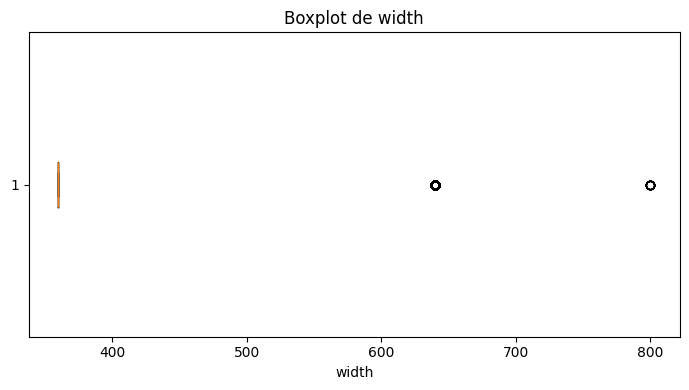

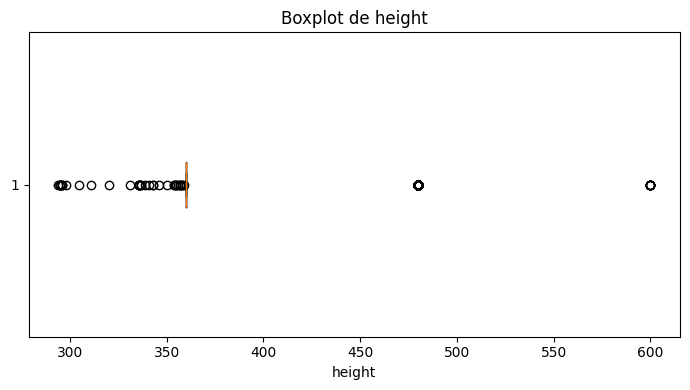

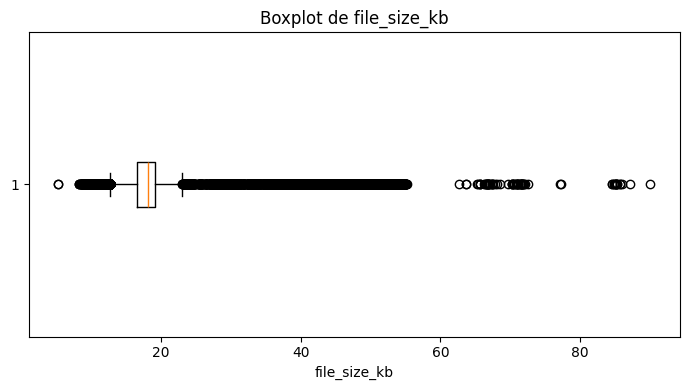

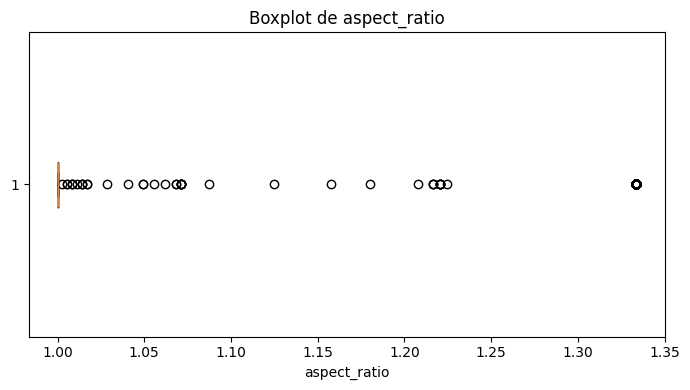

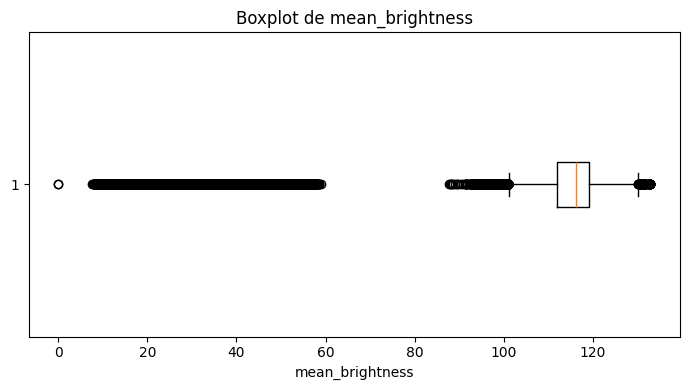

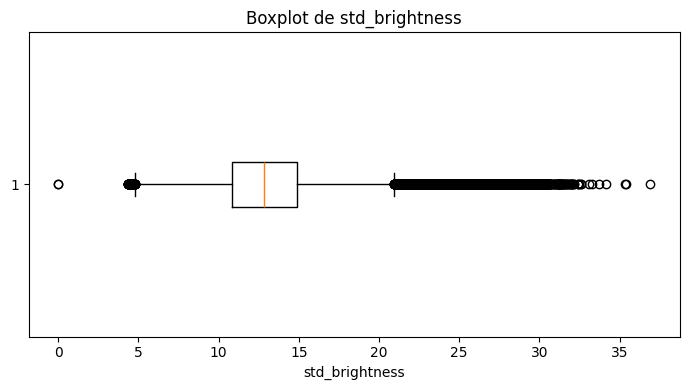

In [21]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.xlabel(col)
    plt.title(f"Boxplot de {col}")
    plt.tight_layout()
    plt.show()

In [22]:
outliers_size, lower, upper = detect_outliers_iqr(df, "file_size_kb")

outliers_size.sort_values("file_size_kb", ascending=False).head(10)

,dataset,path,filename,label,width,height,mode,channels,file_size_kb,aspect_ratio,mean_brightness,std_brightness
286632,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,07114002.jpg,07114,800,600,RGB,3,90.052734,1.333333,14.191719,16.710683
286623,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,07114001.jpg,07114,800,600,RGB,3,87.131836,1.333333,13.964738,16.927543
289116,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,08249012.jpg,08248,640,480,RGB,3,85.986328,1.333333,33.938988,26.686695
289118,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,08249001.jpg,08248,640,480,RGB,3,85.770508,1.333333,33.153682,25.561164
289115,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,08249013.jpg,08248,640,480,RGB,3,85.755859,1.333333,33.635469,26.292556
289111,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,08249011.jpg,08248,640,480,RGB,3,85.248047,1.333333,32.503060,26.631330
289121,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,08249002.jpg,08248,640,480,RGB,3,85.214844,1.333333,33.311986,26.495430
289113,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,08249006.jpg,08248,640,480,RGB,3,85.183594,1.333333,32.212458,24.922578
289119,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,08249009.jpg,08248,640,480,RGB,3,85.149414,1.333333,32.277764,24.934082
289112,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,08249010.jpg,08248,640,480,RGB,3,85.115234,1.333333,32.388607,25.364704


Se identificaron posibles valores atípicos en variables como tamaño de archivo, resolución y brillo. Debido a que se trata de imágenes, estos valores no deben eliminarse automáticamente, ya que podrían representar condiciones reales de captura. Sin embargo, sí justifican aplicar un preprocesamiento homogéneo.

In [23]:
#Visualización de imágenes aleatorias

def show_random_images(data, n=12, label=None, dataset=None):
    temp = data.copy()

    if label is not None:
        temp = temp[temp["label"] == label]

    if dataset is not None:
        temp = temp[temp["dataset"] == dataset]

    sample = temp.sample(min(n, len(temp)), random_state=42)

    plt.figure(figsize=(12, 8))

    for i, row in enumerate(sample.itertuples(), 1):
        img = Image.open(row.path)
        plt.subplot(3, 4, i)
        plt.imshow(img)
        plt.title(f"{row.dataset}\nClase: {row.label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

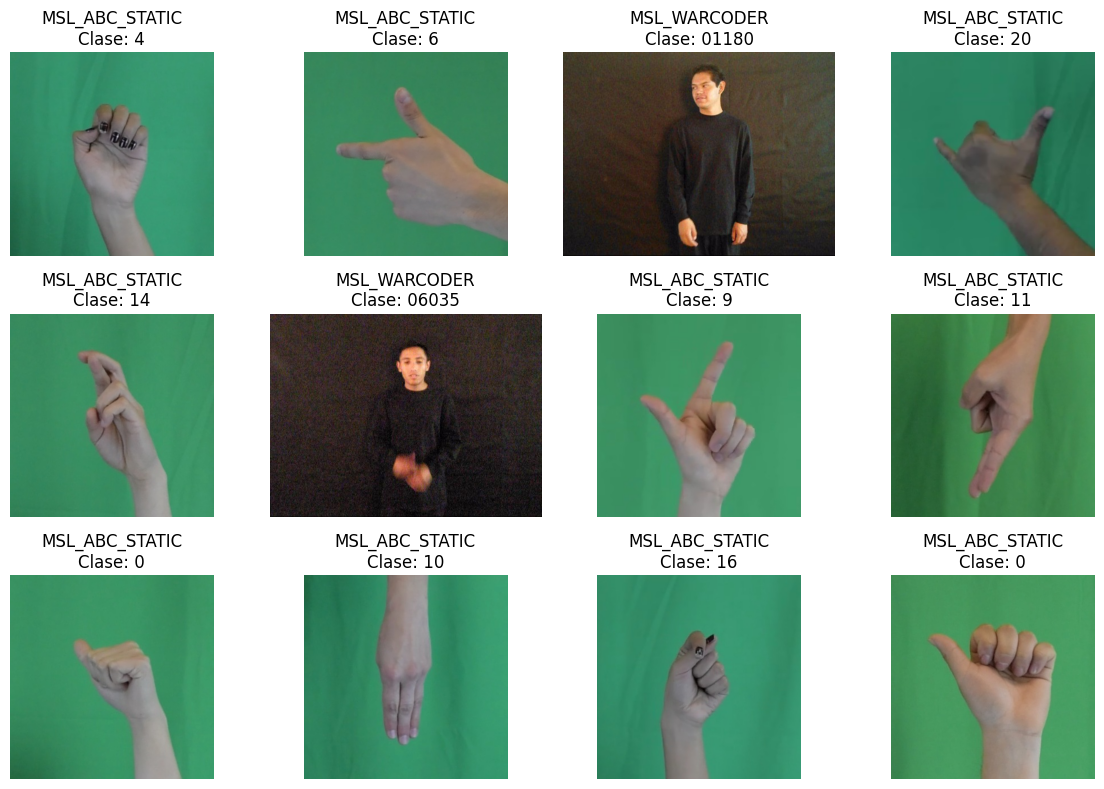

In [24]:
show_random_images(df, n=12)

La inspección visual permite identificar diferencias en iluminación, fondo, posición de la mano, encuadre y resolución. Estas diferencias pueden afectar el desempeño del modelo, por lo que se recomienda aplicar técnicas de normalización y aumento de datos.

In [25]:
#Análisis bivariado: clase vs brillo

brightness_by_class = df.groupby("label")["mean_brightness"].agg(["mean", "median", "std", "count"]).reset_index()
brightness_by_class = brightness_by_class.sort_values("mean", ascending=False)

brightness_by_class.head(10)

,label,mean,median,std,count
2198,1,120.014567,119.978040,3.266465,13756
0,0,119.065804,119.365583,3.633969,13898
2461,4,118.581551,118.837816,3.857715,13753
2462,5,118.538090,118.575540,3.555482,13637
2460,3,118.432729,118.700432,3.328321,13633
2466,9,117.934823,118.266304,3.027050,13457
2465,8,117.879979,118.376798,3.358545,13680
2453,15,117.237922,117.524282,3.116477,13178
2451,13,117.219600,117.472292,2.797451,13282
2452,14,117.069238,117.126489,3.071979,13434


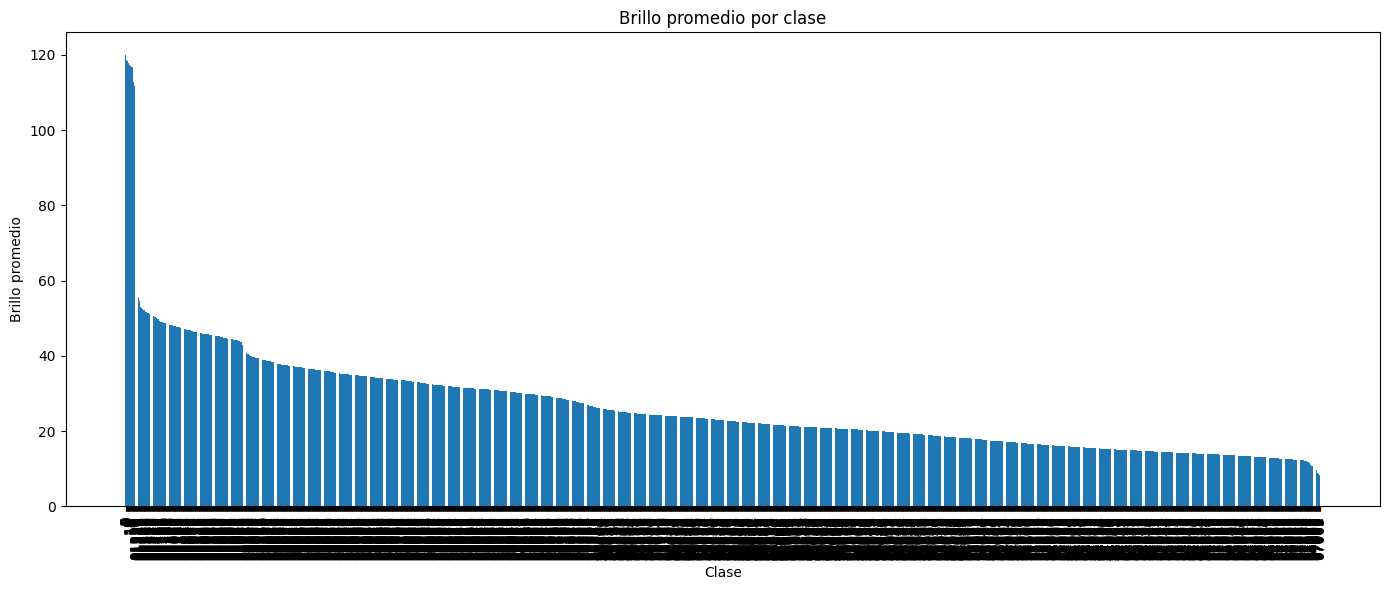

In [26]:
plt.figure(figsize=(14, 6))
plt.bar(brightness_by_class["label"], brightness_by_class["mean"])
plt.xticks(rotation=90)
plt.xlabel("Clase")
plt.ylabel("Brillo promedio")
plt.title("Brillo promedio por clase")
plt.tight_layout()
plt.show()

Existen diferencias en el brillo promedio entre clases. Esto puede estar relacionado con distintas condiciones de iluminación al momento de capturar las imágenes. Para reducir este efecto, se recomienda normalizar los pixeles y aplicar aumento de datos con variaciones moderadas de brillo.

In [27]:
#Correlación entre variables numéricas

corr_matrix = df[numeric_cols].corr()

corr_matrix

,width,height,file_size_kb,aspect_ratio,mean_brightness,std_brightness
width,1.000000,0.999899,0.656882,0.999845,-0.978776,0.640631
height,0.999899,1.000000,0.656950,0.999493,-0.978600,0.640376
file_size_kb,0.656882,0.656950,1.000000,0.656616,-0.607579,0.610709
aspect_ratio,0.999845,0.999493,0.656616,1.000000,-0.978725,0.640775
mean_brightness,-0.978776,-0.978600,-0.607579,-0.978725,1.000000,-0.588354
std_brightness,0.640631,0.640376,0.610709,0.640775,-0.588354,1.000000


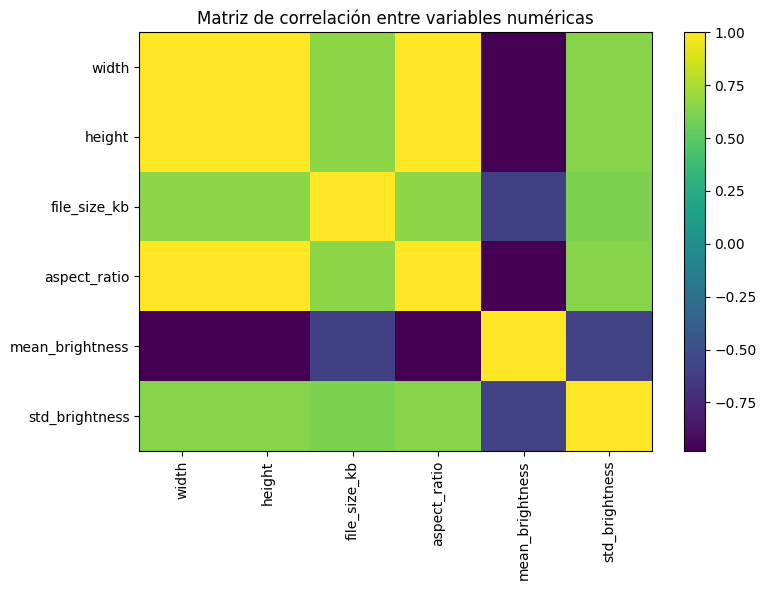

In [28]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

Se identifican relaciones esperadas entre ancho, alto y tamaño de archivo. Estas variables describen características técnicas de las imágenes, pero no necesariamente explican de forma directa la clase objetivo. Aun así, ayudan a detectar diferencias estructurales entre imágenes y datasets.

Valor mínimo original: 3
Valor máximo original: 200
Valor mínimo normalizado: 0.011764705882352941
Valor máximo normalizado: 0.7843137254901961


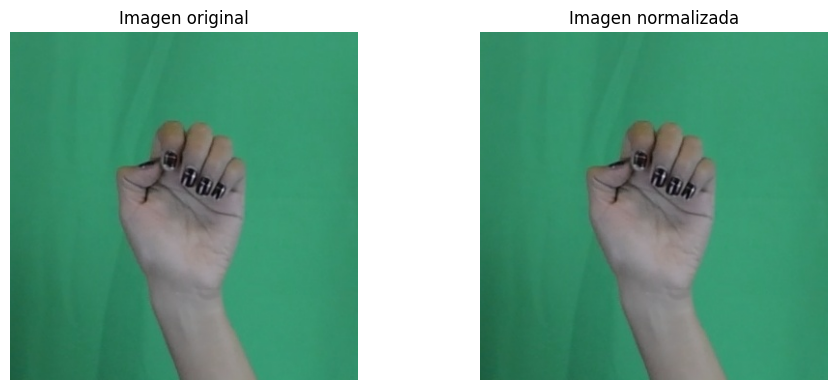

In [29]:
#Normalizacion de imagenes

sample_path = df.sample(1, random_state=42)["path"].values[0]

img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_normalized = img_rgb / 255.0

print("Valor mínimo original:", img_rgb.min())
print("Valor máximo original:", img_rgb.max())
print("Valor mínimo normalizado:", img_normalized.min())
print("Valor máximo normalizado:", img_normalized.max())

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_normalized)
plt.title("Imagen normalizada")
plt.axis("off")

plt.tight_layout()
plt.show()

Sí se recomienda normalizar las imágenes. La normalización convierte los valores de pixel de un rango de 0 a 255 a un rango de 0 a 1. Esto facilita el entrenamiento de modelos de machine learning y deep learning, al mejorar la estabilidad numérica y reducir diferencias de escala.

Shape procesada: (224, 224, 3)


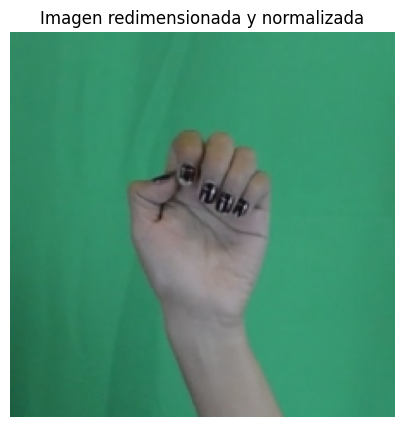

In [30]:
#Redimensionamiento de imagenes
IMG_SIZE = (224, 224)

def load_and_preprocess_image(path, img_size=IMG_SIZE):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, img_size)
    img_normalized = img_resized / 255.0
    return img_normalized

sample_processed = load_and_preprocess_image(sample_path)

print("Shape procesada:", sample_processed.shape)

plt.figure(figsize=(5, 5))
plt.imshow(sample_processed)
plt.title("Imagen redimensionada y normalizada")
plt.axis("off")
plt.show()

In [31]:
#Revision de duplicados

duplicates_filename = df[df.duplicated(subset=["filename"], keep=False)]

print("Posibles duplicados por nombre:", len(duplicates_filename))

duplicates_filename.head()

Posibles duplicados por nombre: 110


,dataset,path,filename,label,width,height,mode,channels,file_size_kb,aspect_ratio,mean_brightness,std_brightness
282266,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,02149011.jpg,02149,640,480,RGB,3,12.710938,1.333333,20.147191,21.534429
282267,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,02149003.jpg,02149,640,480,RGB,3,13.114258,1.333333,19.265674,19.719264
282269,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,02149001.jpg,02149,640,480,RGB,3,12.180664,1.333333,19.425710,19.117040
282270,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,02149005.jpg,02149,640,480,RGB,3,13.235352,1.333333,20.359668,21.295242
282271,MSL_WARCODER,data/msl_warcoder/Mexican sign language datase...,02149009.jpg,02149,640,480,RGB,3,12.892578,1.333333,20.033066,21.697726


In [32]:
duplicates_full = df[df.duplicated(subset=["filename", "file_size_kb", "label"], keep=False)]

print("Posibles duplicados por nombre, tamaño y clase:", len(duplicates_full))

duplicates_full.head()

Posibles duplicados por nombre, tamaño y clase: 0


,dataset,path,filename,label,width,height,mode,channels,file_size_kb,aspect_ratio,mean_brightness,std_brightness


Se revisaron posibles duplicados a partir del nombre del archivo, tamaño y clase. Esta revisión es importante para evitar que una misma imagen aparezca tanto en entrenamiento como en validación, lo cual podría generar una evaluación artificialmente alta del modelo.

In [33]:
#Particion train/test estratificada
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (248900, 12)
Test: (62225, 12)


In [34]:
train_distribution = train_df["label"].value_counts(normalize=True).sort_index()
test_distribution = test_df["label"].value_counts(normalize=True).sort_index()

distribution_comparison = pd.DataFrame({
    "train_percent": train_distribution * 100,
    "test_percent": test_distribution * 100
})

distribution_comparison.head(20)

,train_percent,test_percent
label,,
0,4.466854,4.467658
01001,0.004018,0.004821
01002,0.004821,0.004821
01003,0.004018,0.004821
01004,0.003616,0.003214
01005,0.004419,0.004821
01006,0.004018,0.004821
01007,0.004821,0.004821
01008,0.004018,0.003214


Se recomienda utilizar una partición estratificada para conservar la proporción de clases entre los conjuntos de entrenamiento y prueba. Esta decisión es importante cuando existe desequilibrio en la variable objetivo.

In [35]:
#Guardar dataset

df.to_csv("eda_mexican_sign_language_images.csv", index=False)

df_videos.to_csv("eda_mexican_sign_language_videos.csv", index=False)

print("Archivos exportados correctamente.")

Archivos exportados correctamente.


In [36]:
from google.colab import files

files.download("eda_mexican_sign_language_images.csv")
files.download("eda_mexican_sign_language_videos.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# Conclusiones del Analisis Exploratorio

A partir del análisis exploratorio de datos, se consolidaron los archivos de los repositorios seleccionados en una tabla maestra, donde cada imagen representa una observación. Esto permitió analizar variables como clase, dataset de origen, resolución, tamaño de archivo, relación de aspecto, brillo promedio y desviación del brillo.

No se identificaron valores faltantes relevantes en las variables principales. Sin embargo, se realizó una validación de imágenes corruptas o no legibles, las cuales fueron excluidas del análisis para evitar errores posteriores.

La variable objetivo corresponde a la clase o seña representada en cada imagen, por lo que el problema puede formularse como una clasificación multiclase. El análisis de distribución evidenció que pueden existir diferencias en la cantidad de imágenes por clase, lo cual representa un posible desequilibrio en los datos.

También se observaron diferencias en resolución, tamaño de archivo y brillo, lo que sugiere que las imágenes provienen de condiciones de captura heterogéneas. Por ello, se recomienda aplicar redimensionamiento, normalización de pixeles y aumento de datos moderado.

Finalmente, se concluye que el conjunto de datos es adecuado para un modelo de clasificación de imágenes de Lengua de Señas Mexicana, siempre que se apliquen pasos de limpieza, estandarización y partición estratificada para reducir sesgos y mejorar la capacidad de generalización del modelo.

# Feature Engineering

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_fe = df.copy()

df_fe.head()

,dataset,path,filename,label,width,height,mode,channels,file_size_kb,aspect_ratio,mean_brightness,std_brightness
0,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-3...,S18-M-3-29.jpg,10,360,360,RGB,3,16.331055,1.0,107.779769,19.240856
1,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S20-M-2...,S20-M-2-36.jpg,10,360,360,RGB,3,17.469727,1.0,117.632346,11.554279
2,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-3...,S18-M-3-19.jpg,10,360,360,RGB,3,13.806641,1.0,107.910895,19.155192
3,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-2...,S18-M-2-30.jpg,10,360,360,RGB,3,19.101562,1.0,110.864468,18.984211
4,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-2...,S18-M-2-16.jpg,10,360,360,RGB,3,15.196289,1.0,110.065826,19.730439


In [39]:
#Generación de nuevas caracteristicas

# Área total de la imagen
df_fe["image_area"] = df_fe["height"] * df_fe["width"]

# Relación entre tamaño del archivo y área de imagen
df_fe["size_per_pixel"] = df_fe["file_size_kb"] / df_fe["image_area"]

# Indicador de imagen muy oscura
df_fe["is_dark"] = np.where(df_fe["mean_brightness"] < 50, 1, 0)

# Indicador de imagen muy brillante
df_fe["is_bright"] = np.where(df_fe["mean_brightness"] > 200, 1, 0)

# Indicador de bajo contraste
df_fe["low_contrast"] = np.where(df_fe["std_brightness"] < 30, 1, 0)

# Indicador de imagen panorámica o muy alargada
df_fe["is_wide"] = np.where(df_fe["aspect_ratio"] > 1.5, 1, 0)

# Indicador de imagen vertical
df_fe["is_vertical"] = np.where(df_fe["aspect_ratio"] < 0.75, 1, 0)

df_fe.head()

,dataset,path,filename,label,width,height,mode,channels,file_size_kb,aspect_ratio,mean_brightness,std_brightness,image_area,size_per_pixel,is_dark,is_bright,low_contrast,is_wide,is_vertical
0,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-3...,S18-M-3-29.jpg,10,360,360,RGB,3,16.331055,1.0,107.779769,19.240856,129600,0.000126,0,0,1,0,0
1,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S20-M-2...,S20-M-2-36.jpg,10,360,360,RGB,3,17.469727,1.0,117.632346,11.554279,129600,0.000135,0,0,1,0,0
2,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-3...,S18-M-3-19.jpg,10,360,360,RGB,3,13.806641,1.0,107.910895,19.155192,129600,0.000107,0,0,1,0,0
3,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-2...,S18-M-2-30.jpg,10,360,360,RGB,3,19.101562,1.0,110.864468,18.984211,129600,0.000147,0,0,1,0,0
4,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-2...,S18-M-2-16.jpg,10,360,360,RGB,3,15.196289,1.0,110.065826,19.730439,129600,0.000117,0,0,1,0,0


Se generaron nuevas características descriptivas de las imágenes para capturar información adicional sobre tamaño, resolución, brillo, contraste y proporción visual. Estas variables pueden ser útiles para identificar diferencias estructurales entre clases, detectar imágenes con baja calidad visual y mejorar la representación de los datos antes del entrenamiento de modelos de aprendizaje automático.

In [41]:
#Discretización o binning

# Binning de tamaño de archivo
df_fe["file_size_category"] = pd.cut(
    df_fe["file_size_kb"],
    bins=[0, 50, 200, 500, np.inf],
    labels=["muy_pequeño", "pequeño", "mediano", "grande"]
)

# Binning de brillo promedio
df_fe["brightness_category"] = pd.cut(
    df_fe["mean_brightness"],
    bins=[0, 50, 150, 220, 255],
    labels=["oscura", "normal", "brillante", "muy_brillante"]
)

# Binning de área de imagen
df_fe["area_category"] = pd.qcut(
    df_fe["image_area"],
    q=4,
    labels=False,
    duplicates="drop"
)

df_fe["area_category"] = df_fe["area_category"].map({
    0: "baja",
    1: "media",
    2: "alta"
})

Durante la discretización de la variable image_area, se identificó que muchas imágenes comparten dimensiones similares o iguales, lo que generó valores repetidos en los puntos de corte al aplicar qcut. Por ello, se utilizó el parámetro duplicates="drop", permitiendo eliminar cortes duplicados y generar únicamente los grupos posibles. Esta decisión es adecuada porque evita crear categorías artificiales cuando los datos no presentan suficiente variabilidad en el área de imagen.

In [42]:
#Codificacion de variables categoricas
categorical_cols = [
    "file_size_category",
    "brightness_category",
    "area_category"
]

df_encoded = pd.get_dummies(
    df_fe,
    columns=categorical_cols,
    drop_first=True
)

df_encoded.head()

,dataset,path,filename,label,width,height,mode,channels,file_size_kb,aspect_ratio,...,low_contrast,is_wide,is_vertical,file_size_category_pequeño,file_size_category_mediano,file_size_category_grande,brightness_category_normal,brightness_category_brillante,brightness_category_muy_brillante,area_category_media
0,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-3...,S18-M-3-29.jpg,10,360,360,RGB,3,16.331055,1.0,...,1,0,0,False,False,False,True,False,False,False
1,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S20-M-2...,S20-M-2-36.jpg,10,360,360,RGB,3,17.469727,1.0,...,1,0,0,False,False,False,True,False,False,False
2,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-3...,S18-M-3-19.jpg,10,360,360,RGB,3,13.806641,1.0,...,1,0,0,False,False,False,True,False,False,False
3,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-2...,S18-M-2-30.jpg,10,360,360,RGB,3,19.101562,1.0,...,1,0,0,False,False,False,True,False,False,False
4,MSL_ABC_STATIC,data/msl_abc/MSL-ABC/lsm-abc-B/test/10/S18-M-2...,S18-M-2-16.jpg,10,360,360,RGB,3,15.196289,1.0,...,1,0,0,False,False,False,True,False,False,False


In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded["label_encoded"] = le.fit_transform(df_encoded["label"])

df_encoded[["label", "label_encoded"]].head()

,label,label_encoded
0,10,2199
1,10,2199
2,10,2199
3,10,2199
4,10,2199


Se utilizó One Hot Encoding para transformar variables categóricas generadas en variables binarias, evitando imponer un orden artificial entre categorías. Para la variable objetivo label, se aplicó Label Encoding, ya que representa las clases que posteriormente podrían ser utilizadas en un modelo de clasificación.

In [44]:
#Transformación logartimica, esta se aplica ya que encontramos variables altamente sesgadas.

skewed_cols = [
    "file_size_kb",
    "height",
    "width",
    "aspect_ratio",
    "image_area",
    "size_per_pixel"
]

for col in skewed_cols:
    df_encoded[f"log_{col}"] = np.log1p(df_encoded[col])

df_encoded[[col for col in df_encoded.columns if col.startswith("log_")]].head()

,log_file_size_kb,log_height,log_width,log_aspect_ratio,log_image_area,log_size_per_pixel
0,2.852500,5.888878,5.888878,0.693147,11.772216,0.000126
1,2.916133,5.888878,5.888878,0.693147,11.772216,0.000135
2,2.695076,5.888878,5.888878,0.693147,11.772216,0.000107
3,3.000798,5.888878,5.888878,0.693147,11.772216,0.000147
4,2.784782,5.888878,5.888878,0.693147,11.772216,0.000117


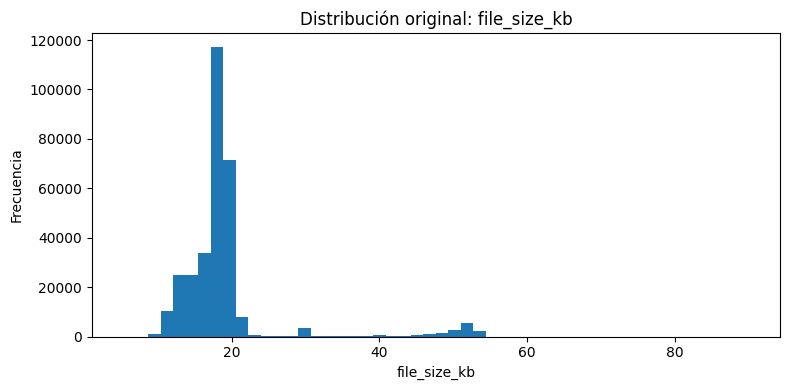

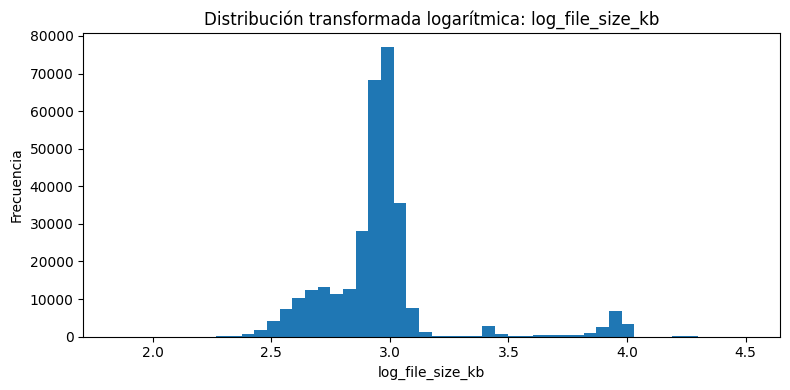

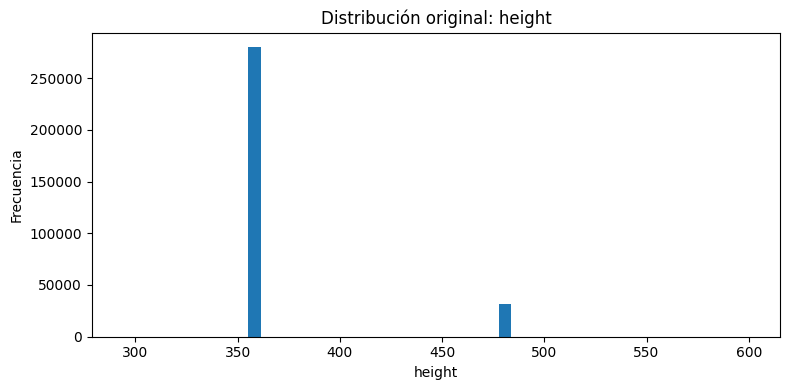

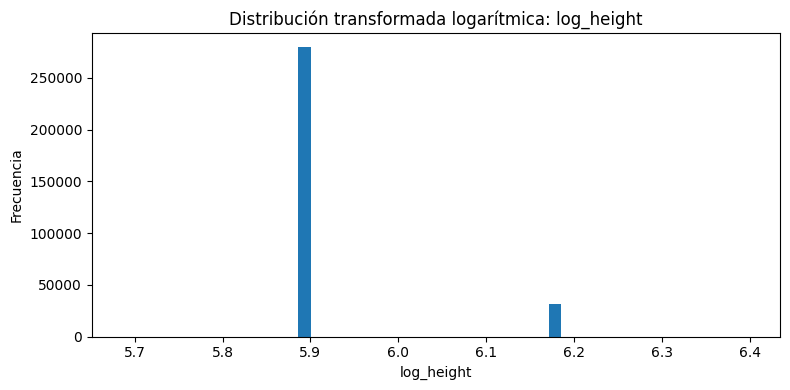

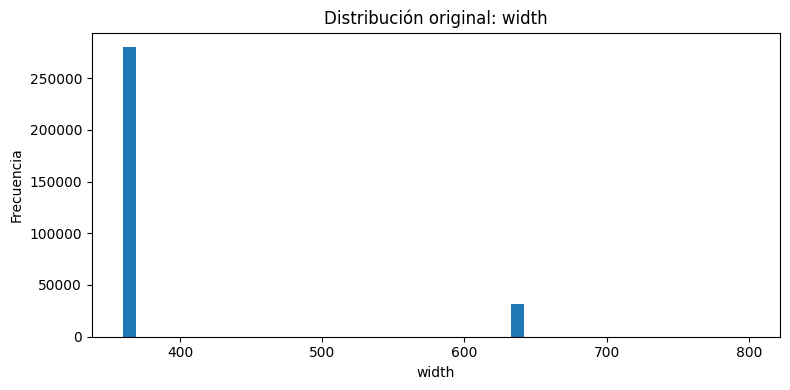

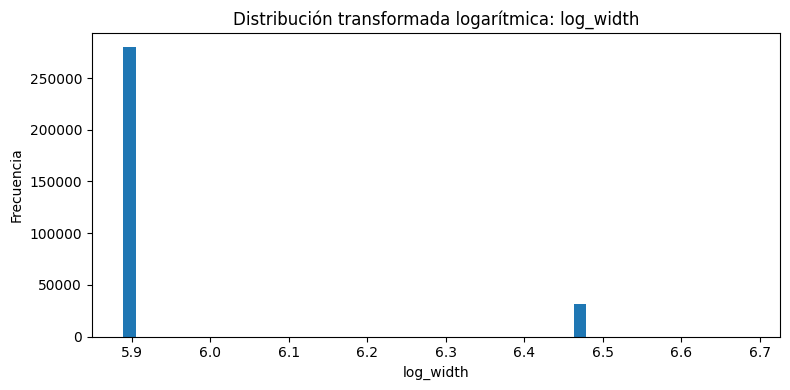

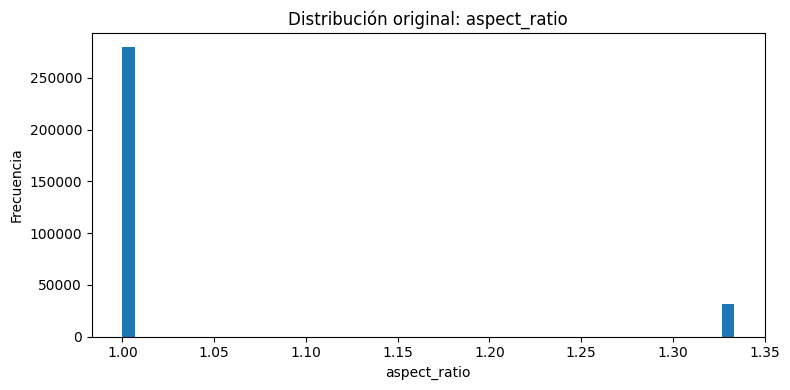

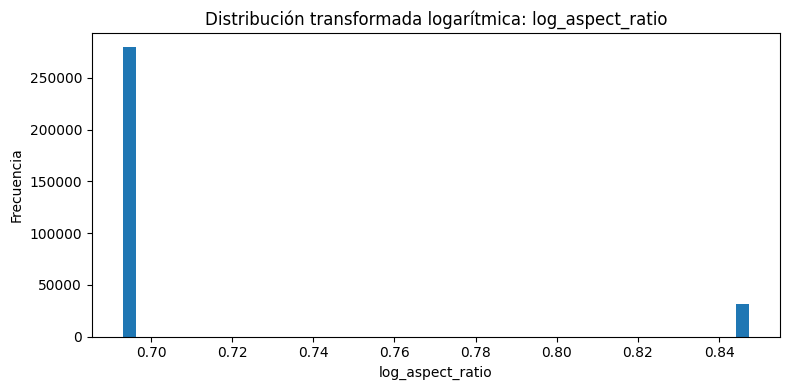

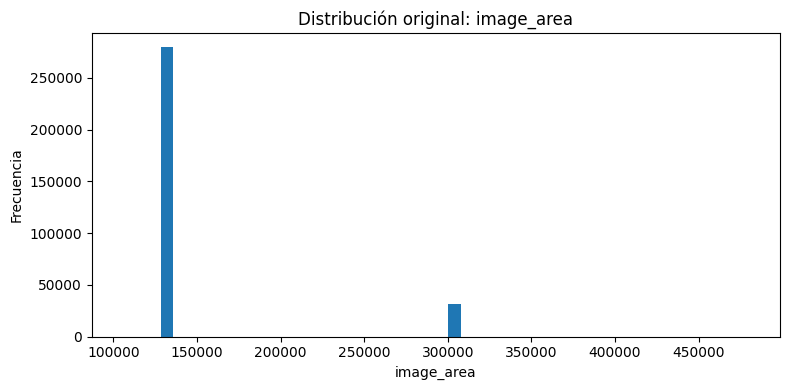

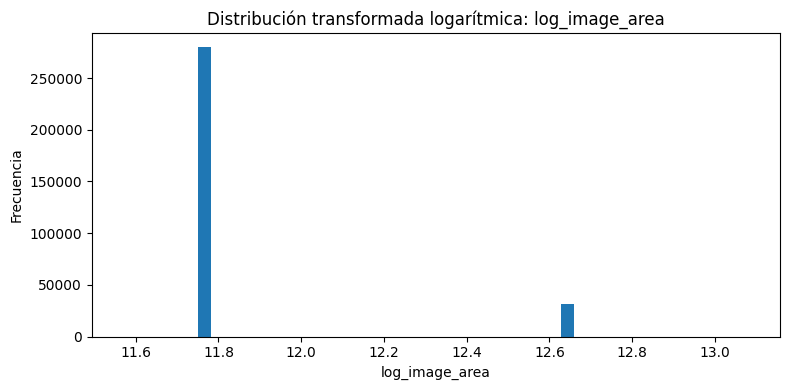

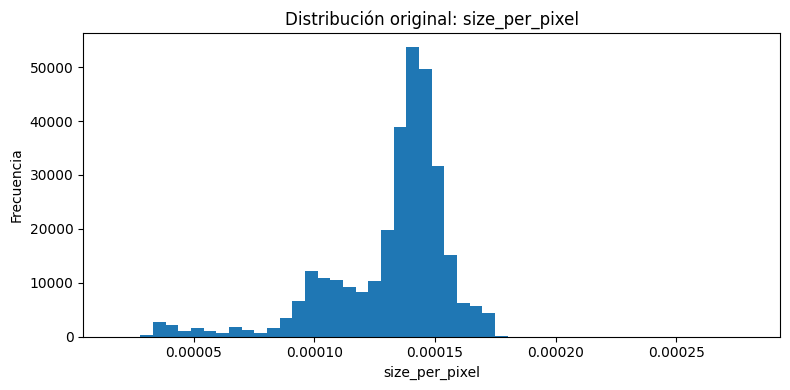

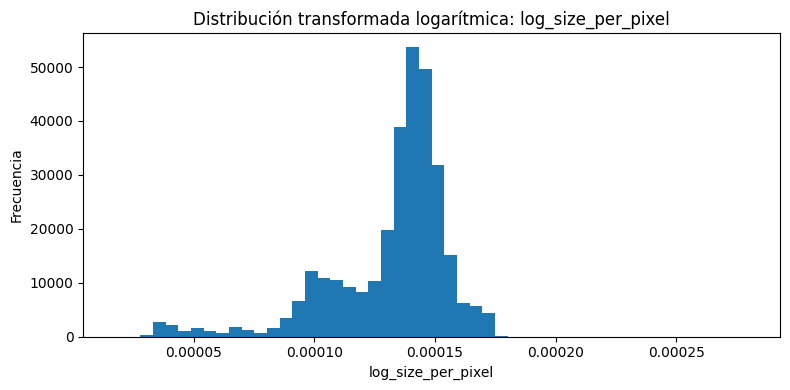

In [45]:
# Se comparara el antes y despues de la transformacion

for col in skewed_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df_encoded[col], bins=50)
    plt.title(f"Distribución original: {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(df_encoded[f"log_{col}"], bins=50)
    plt.title(f"Distribución transformada logarítmica: log_{col}")
    plt.xlabel(f"log_{col}")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

Se aplicó transformación logarítmica a variables con sesgo positivo alto, como file_size_kb, height, width, aspect_ratio e image_area. Esta transformación reduce la influencia de valores extremos y ayuda a obtener distribuciones más estables para el modelado. Se utilizó log1p para evitar problemas con valores iguales a cero.

In [46]:
#Transformación Yeo-Johnson, esto se aplico para variables que pueden tener un sesgo positivo o negativo como mean_brightness

from sklearn.preprocessing import PowerTransformer

power_cols = [
    "mean_brightness",
    "std_brightness"
]

pt = PowerTransformer(method="yeo-johnson")

df_encoded[[f"yj_{col}" for col in power_cols]] = pt.fit_transform(df_encoded[power_cols])

df_encoded[[f"yj_{col}" for col in power_cols]].head()

,yj_mean_brightness,yj_std_brightness
0,-0.577241,1.438458
1,0.423991,-0.347129
2,-0.565908,1.423136
3,-0.297144,1.392332
4,-0.372411,1.524621


Se aplicó la transformación Yeo-Johnson a variables relacionadas con el brillo, ya que esta técnica permite tratar distribuciones sesgadas tanto positiva como negativamente. En particular, mean_brightness presentaba sesgo negativo, por lo que Yeo-Johnson resulta más flexible que una transformación logarítmica tradicional.

In [47]:
#Escalamiento de variables numericas, esto se hace para estandarizar las variables para que tengan media 0 y desviacion estandar 1

from sklearn.preprocessing import StandardScaler

numeric_features = [
    "file_size_kb",
    "height",
    "width",
    "aspect_ratio",
    "mean_brightness",
    "std_brightness",
    "image_area",
    "size_per_pixel",
    "log_file_size_kb",
    "log_height",
    "log_width",
    "log_aspect_ratio",
    "log_image_area",
    "log_size_per_pixel",
    "yj_mean_brightness",
    "yj_std_brightness"
]

scaler = StandardScaler()

df_scaled = df_encoded.copy()
df_scaled[numeric_features] = scaler.fit_transform(df_scaled[numeric_features])

df_scaled[numeric_features].head()

,file_size_kb,height,width,aspect_ratio,mean_brightness,std_brightness,image_area,size_per_pixel,log_file_size_kb,log_height,log_width,log_aspect_ratio,log_image_area,log_size_per_pixel,yj_mean_brightness,yj_std_brightness
0,-0.364860,-0.334899,-0.335076,-0.335195,0.027632,1.497842,-0.33501,-0.238519,-0.386935,-0.334881,-0.335086,-0.335198,-0.335028,-0.238502,-0.577241,1.438458
1,-0.213650,-0.334899,-0.335076,-0.335195,0.381918,-0.440908,-0.33501,0.113053,-0.148751,-0.334881,-0.335086,-0.335198,-0.335028,0.113063,0.423991,-0.347129
2,-0.700089,-0.334899,-0.335076,-0.335195,0.032347,1.476236,-0.33501,-1.017945,-0.976187,-0.334881,-0.335086,-0.335198,-0.335028,-1.017926,-0.565908,1.423136
3,0.003050,-0.334899,-0.335076,-0.335195,0.138554,1.433110,-0.33501,0.616891,0.168156,-0.334881,-0.335086,-0.335198,-0.335028,0.616886,-0.297144,1.392332
4,-0.515551,-0.334899,-0.335076,-0.335195,0.109835,1.621328,-0.33501,-0.588884,-0.640408,-0.334881,-0.335086,-0.335198,-0.335028,-0.588864,-0.372411,1.524621


Se aplicó estandarización a las variables numéricas para colocarlas en una escala comparable. Esto es importante para algoritmos sensibles a la magnitud de las variables, como PCA, modelos lineales, SVM, KNN o redes neuronales. La estandarización evita que variables con valores grandes, como área o tamaño de archivo, dominen el aprendizaje del modelo.

In [ ]:
#Fase 2 Seleccion de caracterisiticas
#Separar variables predictoras y variable objetivo

In [48]:
# Eliminar columnas no numéricas o que no serán usadas directamente
X = df_scaled.drop(columns=["label", "label_encoded"])
y = df_scaled["label_encoded"]

# Quedarse solo con variables numéricas
X = X.select_dtypes(include=["int64", "float64", "uint8", "bool"])

# Convertir booleanos a enteros
X = X.astype(float)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (311125, 29)
Shape de y: (311125,)


In [49]:
#Umbral de varianza
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_var = selector.fit_transform(X)

selected_features_var = X.columns[selector.get_support()]

print("Número original de características:", X.shape[1])
print("Número después de umbral de varianza:", X_var.shape[1])

selected_features_var

Número original de características: 29
Número después de umbral de varianza: 20


Index(['width', 'height', 'file_size_kb', 'aspect_ratio', 'mean_brightness',
       'std_brightness', 'image_area', 'size_per_pixel', 'is_dark',
       'file_size_category_pequeño', 'brightness_category_normal',
       'area_category_media', 'log_file_size_kb', 'log_height', 'log_width',
       'log_aspect_ratio', 'log_image_area', 'log_size_per_pixel',
       'yj_mean_brightness', 'yj_std_brightness'],
      dtype='object')

Se utilizó el método de umbral de varianza para eliminar características con baja variabilidad. Las variables casi constantes aportan poca información al modelo y pueden aumentar innecesariamente el almacenamiento, la complejidad y el tiempo de entrenamiento.

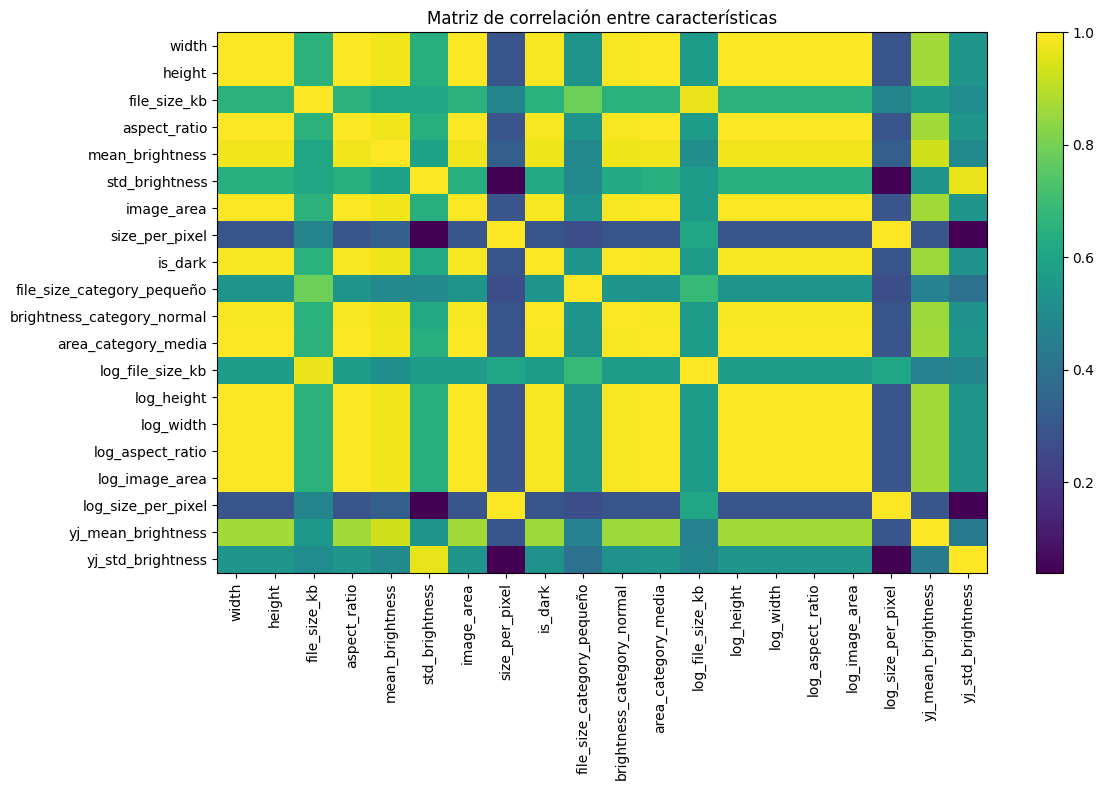

In [50]:
#Correlacion entre variables, para detectar variables redundantes
corr_matrix = X[selected_features_var].corr().abs()

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Matriz de correlación entre características")
plt.tight_layout()
plt.show()

In [51]:
# Y ahora vamos a eliminar variables altamente correlacionadas

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Variables altamente correlacionadas:")
print(high_corr_features)

X_corr = X[selected_features_var].drop(columns=high_corr_features)

print("Número de características después de eliminar correlación alta:", X_corr.shape[1])

Variables altamente correlacionadas:
['height', 'aspect_ratio', 'mean_brightness', 'image_area', 'is_dark', 'brightness_category_normal', 'area_category_media', 'log_file_size_kb', 'log_height', 'log_width', 'log_aspect_ratio', 'log_image_area', 'log_size_per_pixel', 'yj_mean_brightness', 'yj_std_brightness']
Número de características después de eliminar correlación alta: 5


Se analizó la correlación entre variables para identificar características redundantes. Cuando dos variables tienen una correlación muy alta, pueden aportar información similar al modelo. Por ello, se eliminaron variables con correlaciones superiores a 0.90, con el objetivo de reducir redundancia, complejidad y posibles problemas de multicolinealidad.

In [52]:
# Ahora vamos a usar ANOVA para evaluar que variables numercias tienen diferencias significativas entre clases

from sklearn.feature_selection import SelectKBest, f_classif

k = min(10, X_corr.shape[1])

anova_selector = SelectKBest(score_func=f_classif, k=k)
X_anova = anova_selector.fit_transform(X_corr, y)

anova_scores = pd.DataFrame({
    "feature": X_corr.columns,
    "anova_score": anova_selector.scores_,
    "p_value": anova_selector.pvalues_
}).sort_values("anova_score", ascending=False)

anova_scores.head(20)

,feature,anova_score,p_value
0,width,1.399624e+15,0.0
4,file_size_category_pequeño,2.900443e+03,0.0
1,file_size_kb,1.150604e+03,0.0
2,std_brightness,2.938065e+02,0.0
3,size_per_pixel,1.577027e+02,0.0


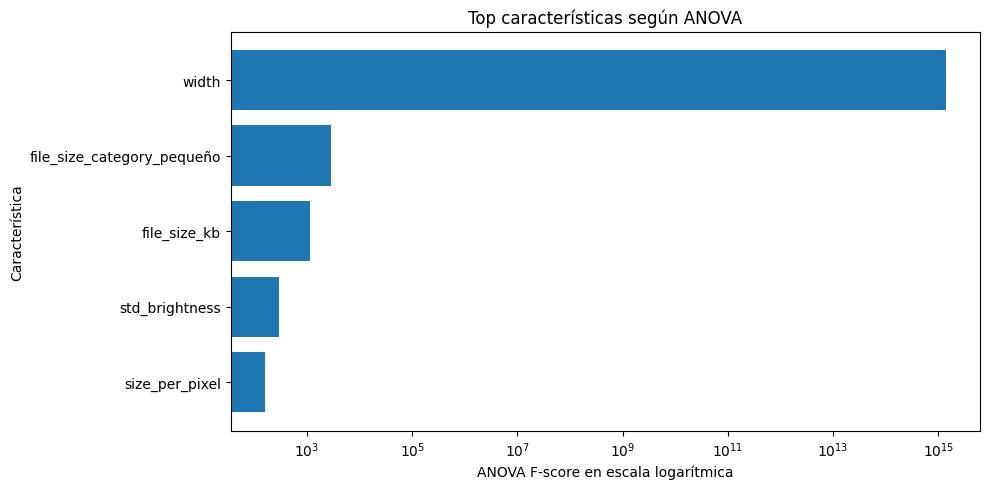

In [54]:
#Visualizar Top variables por ANOVA

top_anova = anova_scores.head(10).copy()

plt.figure(figsize=(10, 5))
plt.barh(top_anova["feature"][::-1], top_anova["anova_score"][::-1])
plt.xscale("log")
plt.xlabel("ANOVA F-score en escala logarítmica")
plt.ylabel("Característica")
plt.title("Top características según ANOVA")
plt.tight_layout()
plt.show()

El análisis ANOVA permitió identificar las características con mayor capacidad de diferenciación entre clases. La variable width presentó el mayor F-score, lo que indica que el ancho de la imagen varía significativamente entre categorías. No obstante, este resultado puede estar relacionado con un sesgo estructural del conjunto de datos, ya que algunas clases podrían contener imágenes con resoluciones particulares. Por esta razón, se considera necesario redimensionar las imágenes antes del entrenamiento del modelo, con el fin de evitar que el clasificador aprenda patrones basados en dimensiones y no en características visuales reales.

In [55]:
# Ahora se hara una verson de analisis sin width y sin height porque en imagenes normalmente se redimensiona todo antes del modelo

# Quitar variables relacionadas directamente con dimensiones
X_corr_no_size = X_corr.drop(
    columns=["width", "height"],
    errors="ignore"
)

from sklearn.feature_selection import SelectKBest, f_classif

k = min(10, X_corr_no_size.shape[1])

anova_selector_no_size = SelectKBest(score_func=f_classif, k=k)
X_anova_no_size = anova_selector_no_size.fit_transform(X_corr_no_size, y)

anova_scores_no_size = pd.DataFrame({
    "feature": X_corr_no_size.columns,
    "anova_score": anova_selector_no_size.scores_,
    "p_value": anova_selector_no_size.pvalues_
}).sort_values("anova_score", ascending=False)

anova_scores_no_size.head(20)

,feature,anova_score,p_value
3,file_size_category_pequeño,2900.442753,0.0
0,file_size_kb,1150.603872,0.0
1,std_brightness,293.806510,0.0
2,size_per_pixel,157.702672,0.0


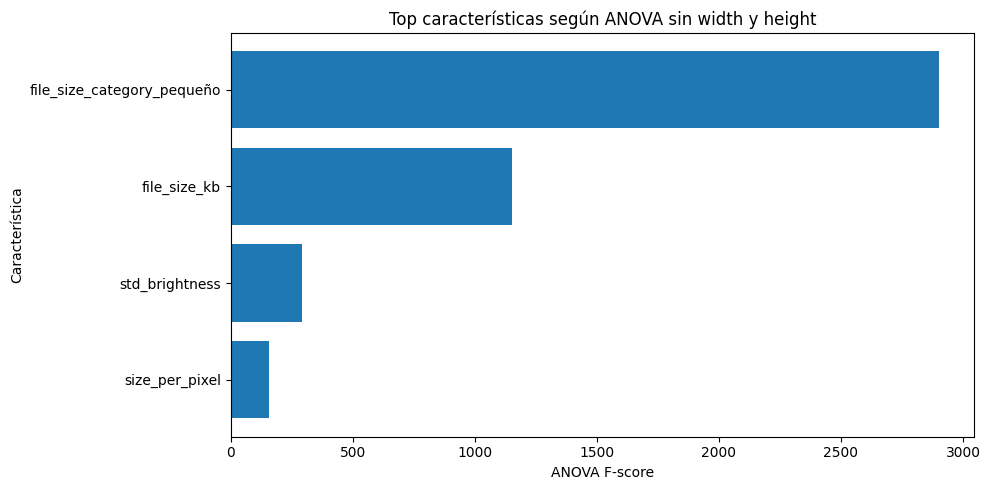

In [56]:
top_anova_no_size = anova_scores_no_size.head(10)

plt.figure(figsize=(10, 5))
plt.barh(
    top_anova_no_size["feature"][::-1],
    top_anova_no_size["anova_score"][::-1]
)
plt.xlabel("ANOVA F-score")
plt.ylabel("Característica")
plt.title("Top características según ANOVA sin width y height")
plt.tight_layout()
plt.show()

Al excluir las variables width y height, el análisis ANOVA muestra que las características más relevantes para diferenciar las clases son file_size_category_pequeño, file_size_kb, std_brightness y size_per_pixel. Esto indica que, más allá de las dimensiones originales de las imágenes, existen diferencias entre clases asociadas al tamaño del archivo, nivel de compresión, variabilidad de brillo y densidad de información por píxel. La variable más importante fue file_size_category_pequeño, lo que sugiere que ciertas clases están relacionadas con imágenes de menor peso o menor complejidad visual.

In [57]:
#Ahora utilizaremos el metodo Chi-cuadrari para evaluar si existe una relacion estadistica entre cada caracteristica y la variable objetivo label_encoded.

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

# Usamos la versión sin width y height para evitar sesgo por resolución
X_chi_base = X_corr_no_size.copy()

# Chi-cuadrado requiere valores no negativos
minmax = MinMaxScaler()

X_chi_input = pd.DataFrame(
    minmax.fit_transform(X_chi_base),
    columns=X_chi_base.columns,
    index=X_chi_base.index
)

X_chi_input.head()

,file_size_kb,std_brightness,size_per_pixel,file_size_category_pequeño
0,0.130158,0.521132,0.414082,0.0
1,0.143593,0.312944,0.447533,0.0
2,0.100372,0.518812,0.339921,0.0
3,0.162847,0.514181,0.495473,0.0
4,0.116769,0.534392,0.380745,0.0


In [58]:
# Seleccionar top características
k = min(10, X_chi_input.shape[1])

chi_selector = SelectKBest(score_func=chi2, k=k)

X_chi = chi_selector.fit_transform(X_chi_input, y)

chi_scores = pd.DataFrame({
    "feature": X_chi_input.columns,
    "chi2_score": chi_selector.scores_,
    "p_value": chi_selector.pvalues_
}).sort_values("chi2_score", ascending=False)

chi_scores.head(20)

,feature,chi2_score,p_value
3,file_size_category_pequeño,288943.938812,0.000000e+00
0,file_size_kb,13625.733910,0.000000e+00
1,std_brightness,6982.776669,0.000000e+00
2,size_per_pixel,3595.269922,1.158272e-45


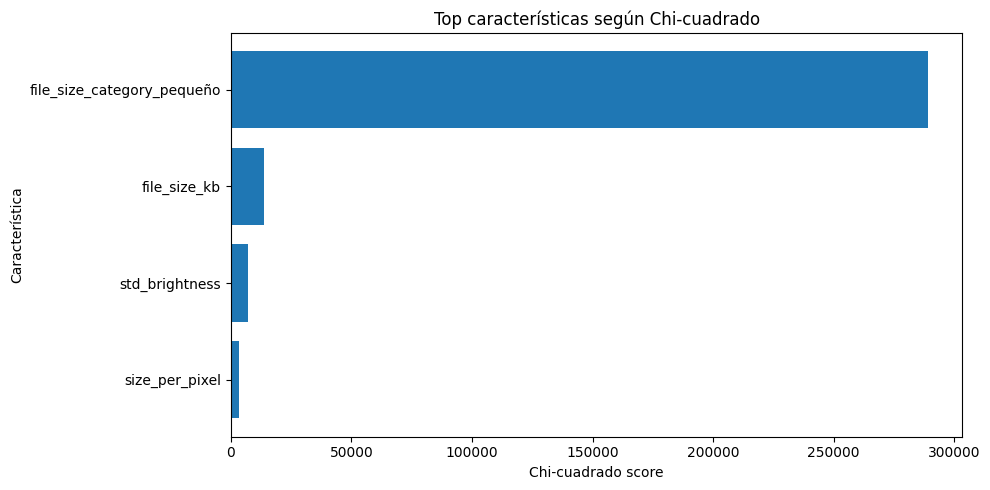

In [59]:
top_chi = chi_scores.head(10)

plt.figure(figsize=(10, 5))
plt.barh(
    top_chi["feature"][::-1],
    top_chi["chi2_score"][::-1]
)
plt.xlabel("Chi-cuadrado score")
plt.ylabel("Característica")
plt.title("Top características según Chi-cuadrado")
plt.tight_layout()
plt.show()

In [61]:
#Ahora vamos a compar ANOVA vs Chi-cuadrado

top_anova_features = set(anova_scores_no_size.head(10)["feature"])
top_chi_features = set(chi_scores.head(10)["feature"])

common_features = top_anova_features.intersection(top_chi_features)

print("Top features ANOVA:")
print(top_anova_features)

print("\nTop features Chi-cuadrado:")
print(top_chi_features)

print("\nFeatures comunes entre ANOVA y Chi-cuadrado:")
print(common_features)

anova_rank = anova_scores_no_size[["feature", "anova_score", "p_value"]].copy()
anova_rank["anova_rank"] = range(1, len(anova_rank) + 1)

chi_rank = chi_scores[["feature", "chi2_score", "p_value"]].copy()
chi_rank["chi2_rank"] = range(1, len(chi_rank) + 1)

comparison_features = anova_rank.merge(
    chi_rank,
    on="feature",
    how="outer",
    suffixes=("_anova", "_chi2")
)

comparison_features = comparison_features.sort_values(
    ["anova_rank", "chi2_rank"]
)

comparison_features.head(20)

Top features ANOVA:
{'size_per_pixel', 'file_size_category_pequeño', 'file_size_kb', 'std_brightness'}

Top features Chi-cuadrado:
{'size_per_pixel', 'file_size_category_pequeño', 'file_size_kb', 'std_brightness'}

Features comunes entre ANOVA y Chi-cuadrado:
{'size_per_pixel', 'file_size_kb', 'std_brightness', 'file_size_category_pequeño'}


,feature,anova_score,p_value_anova,anova_rank,chi2_score,p_value_chi2,chi2_rank
0,file_size_category_pequeño,2900.442753,0.0,1,288943.938812,0.000000e+00,1
1,file_size_kb,1150.603872,0.0,2,13625.733910,0.000000e+00,2
3,std_brightness,293.806510,0.0,3,6982.776669,0.000000e+00,3
2,size_per_pixel,157.702672,0.0,4,3595.269922,1.158272e-45,4


Los métodos de selección de características ANOVA y Chi-cuadrado identificaron las mismas variables como las más relevantes: file_size_category_pequeño, file_size_kb, std_brightness y size_per_pixel. Esta coincidencia refuerza la importancia de estas características, ya que ambos métodos, desde enfoques estadísticos diferentes, encontraron relación significativa entre dichas variables y la clase objetivo.

La variable con mayor relevancia fue file_size_category_pequeño, lo que sugiere que ciertas clases están asociadas con imágenes de menor peso. Asimismo, file_size_kb y size_per_pixel indican que el tamaño y la densidad de información del archivo tienen capacidad discriminativa entre clases. Por su parte, std_brightness muestra que la variabilidad del brillo también puede diferenciar ciertas categorías visuales.

Sin embargo, estas variables deben interpretarse con cautela, ya que pueden reflejar características técnicas del archivo, como compresión, resolución o calidad de imagen, más que atributos visuales propios del objeto. Por ello, en etapas posteriores se recomienda redimensionar, normalizar y estandarizar las imágenes antes del entrenamiento del modelo.

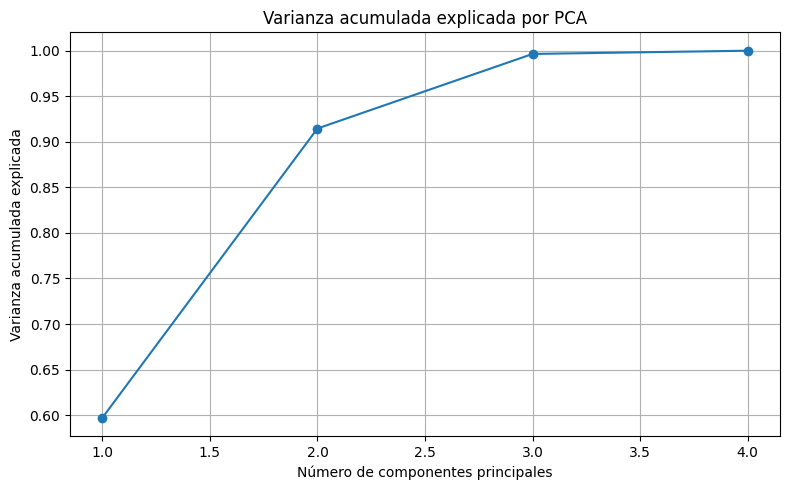

In [62]:
# Ahora aplicaremos PCA, para la extracción de caracteristicas y reduccion de dimensionalidad

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Usamos la base sin width y height
X_pca_base = X_corr_no_size.copy()

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_pca_base)

# Varianza explicada acumulada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza acumulada explicada")
plt.title("Varianza acumulada explicada por PCA")
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
# PCA conservando 95% de la varianza
pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(X_pca_base)

print("Número original de características:", X_pca_base.shape[1])
print("Número de componentes para explicar 95% de varianza:", X_pca_95.shape[1])
print("Varianza explicada acumulada:", round(pca_95.explained_variance_ratio_.sum(), 4))

Número original de características: 4
Número de componentes para explicar 95% de varianza: 3
Varianza explicada acumulada: 0.9964


In [64]:
pca_columns = [f"PC{i+1}" for i in range(X_pca_95.shape[1])]

df_pca = pd.DataFrame(
    X_pca_95,
    columns=pca_columns,
    index=X_pca_base.index
)

df_pca["label"] = df_fe["label"].values
df_pca["label_encoded"] = y.values

df_pca.head()

,PC1,PC2,PC3,label,label_encoded
0,0.471946,-1.100683,-0.999695,10,2199
1,-0.347354,0.361952,0.046196,10,2199
2,-0.118465,-1.700280,-0.893286,10,2199
3,1.070637,-0.388519,-1.066824,10,2199
4,0.280758,-1.451708,-1.026640,10,2199


Se aplicó Análisis de Componentes Principales como técnica de extracción de características con el objetivo de reducir la dimensionalidad del conjunto de datos. A partir de las cuatro características seleccionadas previamente, PCA permitió conservar tres componentes principales, los cuales explican aproximadamente el 99.64% de la varianza acumulada. Esto indica que es posible representar casi toda la información original con una dimensión menos, reduciendo la complejidad del conjunto sin pérdida significativa de información.

In [65]:
# Ahora aplicaremos análisis factorial FA, que es otra tecnica de extraccion de caracteristicas. Mientras que PCA busca maximizar varianza, FA busca identificar factores latentes que expliquen la relacion entre las variables

from sklearn.decomposition import FactorAnalysis
import pandas as pd
import matplotlib.pyplot as plt

# Usamos la misma base que PCA
X_fa_base = X_pca_base.copy()

# Definir número de factores
n_factors = min(3, X_fa_base.shape[1])

fa = FactorAnalysis(n_components=n_factors, random_state=42)

X_fa = fa.fit_transform(X_fa_base)

fa_columns = [f"Factor_{i+1}" for i in range(n_factors)]

df_fa = pd.DataFrame(
    X_fa,
    columns=fa_columns,
    index=X_fa_base.index
)

df_fa["label"] = df_fe["label"].values
df_fa["label_encoded"] = y.values

df_fa.head()

,Factor_1,Factor_2,Factor_3,label,label_encoded
0,-0.117971,0.902993,0.873430,10,2199
1,-0.228111,-0.284652,-0.128447,10,2199
2,-0.404414,1.465658,0.610660,10,2199
3,0.185532,0.243088,1.110960,10,2199
4,-0.230370,1.219757,0.831901,10,2199


In [66]:
loadings = pd.DataFrame(
    fa.components_.T,
    index=X_fa_base.columns,
    columns=fa_columns
)

loadings

,Factor_1,Factor_2,Factor_3
file_size_kb,0.957828,-0.042144,0.033916
std_brightness,0.646248,0.445654,0.309043
size_per_pixel,0.462992,-0.673962,0.130680
file_size_category_pequeño,0.145632,0.020233,-0.052293


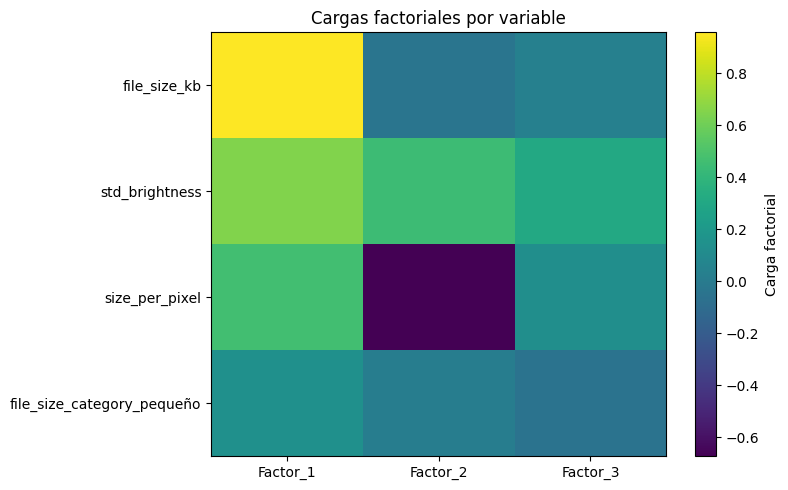

In [67]:
plt.figure(figsize=(8, 5))
plt.imshow(loadings, aspect="auto")
plt.colorbar(label="Carga factorial")
plt.xticks(range(len(loadings.columns)), loadings.columns)
plt.yticks(range(len(loadings.index)), loadings.index)
plt.title("Cargas factoriales por variable")
plt.tight_layout()
plt.show()

Se aplicó Análisis Factorial como técnica de extracción de características para identificar factores latentes entre las variables seleccionadas. El Factor 1 presentó cargas altas en file_size_kb, std_brightness y size_per_pixel, por lo que puede interpretarse como un factor asociado con el tamaño técnico del archivo y la complejidad visual de la imagen. El Factor 2 estuvo principalmente relacionado con size_per_pixel, lo que sugiere diferencias en densidad de información o compresión por píxel. El Factor 3 mostró una aportación menor, vinculada principalmente con variabilidad secundaria del brillo.

Aunque file_size_category_pequeño fue relevante en ANOVA y Chi-cuadrado, sus cargas factoriales fueron bajas. Esto indica que dicha variable tiene relación con la clase objetivo, pero no necesariamente comparte una estructura latente fuerte con el resto de variables. Por ello, el Análisis Factorial se interpreta como una técnica complementaria a los métodos de selección supervisada.

In [68]:
summary_fe = pd.DataFrame({
    "Etapa": [
        "Dataset original numérico",
        "Después de Feature Engineering y codificación",
        "Después de umbral de varianza",
        "Después de eliminar alta correlación",
        "Después de quitar width y height",
        "Después de selección ANOVA / Chi-cuadrado",
        "Después de PCA 95%"
    ],
    "Número de características": [
        df.select_dtypes(include=["int64", "float64"]).shape[1],
        X.shape[1],
        X_var.shape[1],
        X_corr.shape[1],
        X_corr_no_size.shape[1],
        len(common_features),
        X_pca_95.shape[1]
    ]
})

summary_fe

,Etapa,Número de características
0,Dataset original numérico,7
1,Después de Feature Engineering y codificación,29
2,Después de umbral de varianza,20
3,Después de eliminar alta correlación,5
4,Después de quitar width y height,4
5,Después de selección ANOVA / Chi-cuadrado,4
6,Después de PCA 95%,3


In [69]:
final_features = list(common_features)

df_final_features = X_chi_input[final_features].copy()
df_final_features["label"] = df_fe["label"].values
df_final_features["label_encoded"] = y.values

df_final_features.to_csv("dataset_selected_features.csv", index=False)
df_pca.to_csv("dataset_pca_features.csv", index=False)
df_fa.to_csv("dataset_factor_analysis_features.csv", index=False)

df_final_features.head()

,size_per_pixel,file_size_kb,std_brightness,file_size_category_pequeño,label,label_encoded
0,0.414082,0.130158,0.521132,0.0,10,2199
1,0.447533,0.143593,0.312944,0.0,10,2199
2,0.339921,0.100372,0.518812,0.0,10,2199
3,0.495473,0.162847,0.514181,0.0,10,2199
4,0.380745,0.116769,0.534392,0.0,10,2199


# Conclusiones Finales

En la fase de preparación de datos bajo la metodología CRISP-ML, se transformaron los datos crudos del conjunto de imágenes en variables estructuradas útiles para aprendizaje automático. Se generaron características relacionadas con tamaño, área, proporción, brillo, contraste y densidad de información por píxel. Posteriormente, se aplicaron discretización, codificación, transformaciones y escalamiento para tratar sesgos, valores extremos y diferencias de escala.

Para la selección de características se utilizaron métodos de filtrado como umbral de varianza, correlación, ANOVA y Chi-cuadrado. Los métodos ANOVA y Chi-cuadrado coincidieron en seleccionar file_size_category_pequeño, file_size_kb, std_brightness y size_per_pixel, lo que refuerza su relevancia estadística. Además, se excluyeron width y height para evitar sesgos asociados con la resolución original, ya que las imágenes serán redimensionadas antes del modelado.

Finalmente, se aplicaron PCA y Análisis Factorial como técnicas de extracción de características. PCA permitió reducir de cuatro variables a tres componentes principales, conservando el 99.64% de la varianza acumulada. El Análisis Factorial permitió identificar factores latentes asociados con tamaño del archivo, variabilidad del brillo y densidad de información. Estas acciones reducen complejidad, almacenamiento y tiempo de entrenamiento, manteniendo información relevante para la etapa de modelado.